<div style="
    background-color: #F4F6F7; 
    color: #2C3E50; 
    padding: 20px; 
    text-align: center; 
    border-radius: 10px; 
    border-left: 8px solid #5F9EA0; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
    <h1 style="margin: 0; padding-bottom: 5px;">Wine Segmentation Analysis</h1>
    <h3 style="margin-top: 15px; font-weight: normal; font-style: italic; color: #34495E;">
        Unveiling hidden structure in wine chemistry with unsupervised learning
    </h3>
</div>

<h2 style="
    color: #3A6F73;
    font-size: 22px;
    margin-top: 30px;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    border-bottom: 2px solid #E0E6E8;
    padding-bottom: 8px;
">📑 Table of Contents</h2>

| Section | Description |
| :--- | :--- |
| **1. Environmental Setup & Data Ingestion** | Imports, plotting theme, and dataset loading. |
| **2. Data Diagnostics & Preprocessing** | Data quality checks, basic cleaning, and scaling. |
| **3. Heuristic Segmentation (Manual Logic)** | A rule-based baseline segmentation using key chemical features. |
| **4. K-Means Clustering Implementation** | Finding $K$, fitting K-Means, and visualizing clusters with PCA. |
| **5. Cluster Profiling & Interpretation** | Summarizing clusters and assigning descriptive names. |

<h1 style="
    background-color: #F4F6F7;
    color: #2C3E50;
    padding: 20px;
    text-align: center;
    border-radius: 10px;
    border-left: 8px solid #5F9EA0;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
Introduction and Project Overview</h1>

The wine dataset contains **chemical measurements** (e.g., Alcohol, Phenols, Color Intensity) for a set of wines. Our goal is to use **unsupervised learning** to discover natural groupings in the feature space.

This notebook follows the same process as the mall customer segmentation solution:
1. **Preprocessing**: load, clean, and standardize features.
2. **Heuristic baseline**: create an interpretable rule-based segmentation as a reference.
3. **K-Means**: determine an appropriate number of clusters and fit the model.
4. **Interpretation**: profile clusters and translate them into business-friendly labels (here: chemistry-friendly labels).

<h1 style="
    background-color: #F4F6F7;
    color: #2C3E50;
    padding: 20px;
    text-align: center;
    border-radius: 10px;
    border-left: 8px solid #5F9EA0;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
1. Environmental Setup & Data Ingestion</h1>

<h2 style="
    color: #3A6F73;
    font-size: 22px;
    margin-top: 30px;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    border-bottom: 2px solid #E0E6E8;
    padding-bottom: 8px;
">1.1 Importing Libraries & Configuring Aesthetics</h2>

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Visual Aesthetics (The "Corporate Teal" Theme)
teal_corporate_palette = [
    '#5F9EA0', '#3A6F73', '#8FBFC1',
    '#4A5D73', '#2C3E50', '#AAB7B8'
]
my_teal_color = '#3A6F73'
sns.set_palette(teal_corporate_palette)
sns.set_style('whitegrid')

RANDOM_STATE = 42

<h2 style="
    color: #3A6F73;
    font-size: 22px;
    margin-top: 30px;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    border-bottom: 2px solid #E0E6E8;
    padding-bottom: 8px;
">1.2 Data Loading & Initial Inspection</h2>

We load the dataset from the course `DATA/` folder. The helper below tries a few common relative paths so the notebook works whether your working directory is the workspace root or the notebook folder.

In [2]:
candidate_paths = [
    Path('DATA/wine_data.csv'),
    Path('../DATA/wine_data.csv'),
    Path('../../DATA/wine_data.csv'),
    Path('../../../DATA/wine_data.csv'),
]

data_path = None
for p in candidate_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError('Could not find DATA/wine_data.csv from the current working directory. Try running from workspace root.')

df_raw = pd.read_csv(data_path, skipinitialspace=True)
df_raw.shape

(178, 14)

In [3]:
display(df_raw.head())
display(df_raw.tail())

,inputs Alcohol,MalicAcid,Ash,AlcalinityOfAsh,Magnesium,TotalPhenols,flavanoids,NonflavanoidsPhenols,Proanthocyanins,ColorIntensity,Hue,OD280/OD315,Proline,Cultivar
0,12.08,1.33,2.30,23.6,70,2.20,1.59,0.42,1.38,1.74,1.07,3.21,625,1
1,12.08,1.13,2.51,24.0,78,2.00,1.58,0.40,1.40,2.20,1.31,2.72,630,1
2,12.37,1.17,1.92,19.6,78,2.11,2.00,0.27,1.04,4.68,1.12,3.48,510,1
3,13.11,1.01,1.70,15.0,78,2.98,3.18,0.26,2.28,5.30,1.12,3.18,502,1
4,12.04,4.30,2.38,22.0,80,2.10,1.75,0.42,1.35,2.60,0.79,2.57,580,1


,inputs Alcohol,MalicAcid,Ash,AlcalinityOfAsh,Magnesium,TotalPhenols,flavanoids,NonflavanoidsPhenols,Proanthocyanins,ColorIntensity,Hue,OD280/OD315,Proline,Cultivar
173,11.81,2.12,2.74,21.5,134,1.60,0.99,0.14,1.56,2.50,0.95,2.26,625,1
174,12.33,0.99,1.95,14.8,136,1.90,1.85,0.35,2.76,3.40,1.06,2.31,750,1
175,12.99,1.67,2.60,30.0,139,3.30,2.89,0.21,1.96,3.35,1.31,3.50,985,1
176,12.21,1.19,1.75,16.8,151,1.85,1.28,0.14,2.50,2.85,1.28,3.07,718,1
177,12.47,1.52,2.20,19.0,162,2.50,2.27,0.32,3.28,2.60,1.16,2.63,937,1


<h1 style="
    background-color: #F4F6F7;
    color: #2C3E50;
    padding: 20px;
    text-align: center;
    border-radius: 10px;
    border-left: 8px solid #5F9EA0;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
2. Data Diagnostics & Preprocessing</h1>

<h2 style="
    color: #3A6F73;
    font-size: 22px;
    margin-top: 30px;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    border-bottom: 2px solid #E0E6E8;
    padding-bottom: 8px;
">2.1 Basic Cleaning (Columns & Types)</h2>

The dataset has a small formatting quirk: the first column name includes the word `inputs`. We also standardize column names and make sure everything is numeric.

In [4]:
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]
df = df.rename(columns=lambda c: c.replace('inputs ', '').strip())
df = df.rename(columns={'inputs Alcohol': 'Alcohol', 'OD280/OD315': 'OD280_OD315'})

# Ensure numeric conversion (if any column contains stray spaces)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   MalicAcid             178 non-null    float64
 2   Ash                   178 non-null    float64
 3   AlcalinityOfAsh       178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   TotalPhenols          178 non-null    float64
 6   flavanoids            178 non-null    float64
 7   NonflavanoidsPhenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   ColorIntensity        178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280_OD315           178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Cultivar              178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [5]:
print('Missing Values in Data:', df.isnull().sum().sum())
print('Duplicated Rows in Data:', df.duplicated().sum())

# Target-like column (known cultivar class) is kept for interpretation, but excluded from clustering
display(df['Cultivar'].value_counts().sort_index())

Missing Values in Data: 0
Duplicated Rows in Data: 0


Cultivar
0    59
1    71
2    48
Name: count, dtype: int64

<h2 style="
    color: #3A6F73;
    font-size: 22px;
    margin-top: 30px;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    border-bottom: 2px solid #E0E6E8;
    padding-bottom: 8px;
">2.2 Statistical Summary</h2>

In [6]:
display(df.describe().T.sort_values('mean', ascending=False))

,count,mean,std,min,25%,50%,75%,max
Proline,178.0,746.893258,314.907474,278.00,500.5000,673.500,985.0000,1680.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
AlcalinityOfAsh,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
ColorIntensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00
OD280_OD315,178.0,2.611685,0.709990,1.27,1.9375,2.780,3.1700,4.00
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
MalicAcid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
TotalPhenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08


<h2 style="
    color: #3A6F73;
    font-size: 22px;
    margin-top: 30px;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    border-bottom: 2px solid #E0E6E8;
    padding-bottom: 8px;
">2.3 Preprocessing: Feature Matrix & Standardization</h2>

K-Means is distance-based, so we standardize features using `StandardScaler` to put all measurements on the same scale.

In [7]:
feature_cols = [c for c in df.columns if c != 'Cultivar']
X = df[feature_cols].copy()

# Make sure all features are numeric
X = X.apply(pd.to_numeric, errors='coerce')
print('Missing values after numeric conversion:', X.isnull().sum().sum())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

Missing values after numeric conversion: 0


(178, 13)

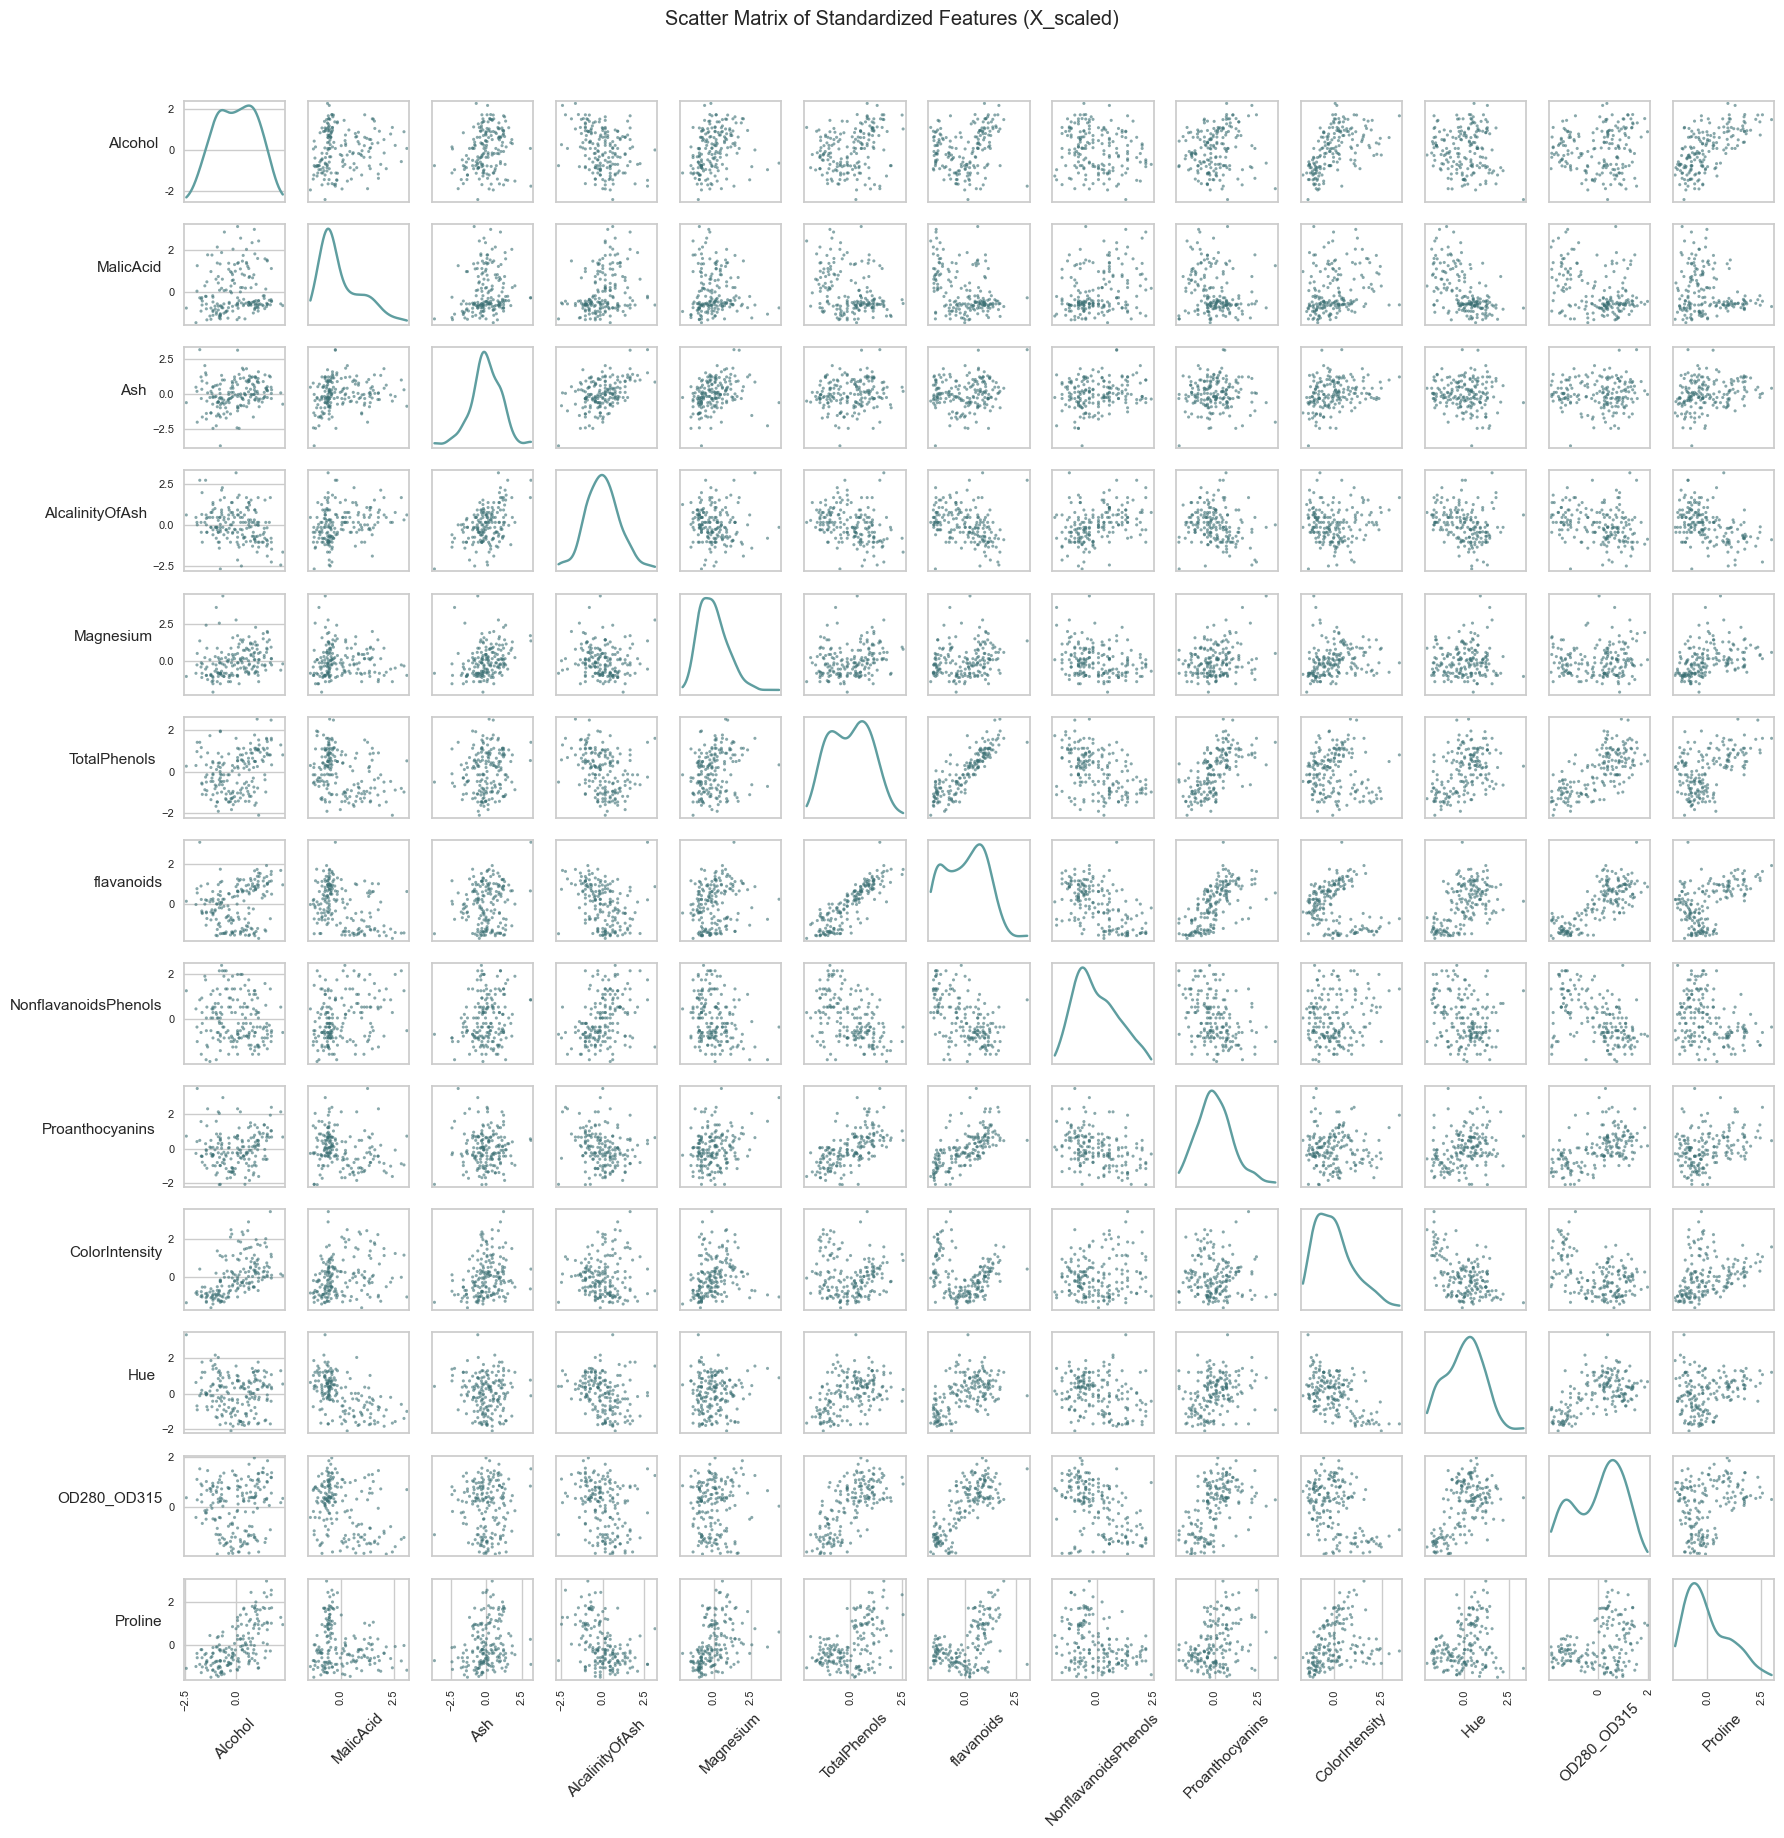

In [10]:
# Scatter matrix for all standardized features (X_scaled)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

axes = pd.plotting.scatter_matrix(
    X_scaled_df,
    figsize=(18, 18),
    diagonal='kde',
    alpha=0.6,
    s=20,
    marker='.',
    color=my_teal_color,
 )

# Improve label readability
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(45)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.suptitle('Scatter Matrix of Standardized Features (X_scaled)', y=1.02)
plt.tight_layout()
plt.show()

<h2 style="
    color: #3A6F73;
    font-size: 22px;
    margin-top: 30px;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    border-bottom: 2px solid #E0E6E8;
    padding-bottom: 8px;
">2.4 Hierarchical Clustering (Visual)</h2>

Just like K-Means, hierarchical clustering uses distances between points, so we use the standardized features (`X_scaled_df`).

We will:
- Plot a **dendrogram for observations** (wines)
- Plot a **dendrogram for variables** (features)
- Plot the data again with **observations ordered** by the hierarchical clustering leaves

In [19]:
# Hierarchical clustering helpers (SciPy)
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import dendrogram, leaves_list

# Linkage for observations (rows) and variables (columns/features)
row_linkage = hierarchy.linkage(X_scaled_df.values, method='ward')
col_linkage = hierarchy.linkage(X_scaled_df.values.T, method='ward')

row_linkage.shape, col_linkage.shape

((177, 4), (12, 4))

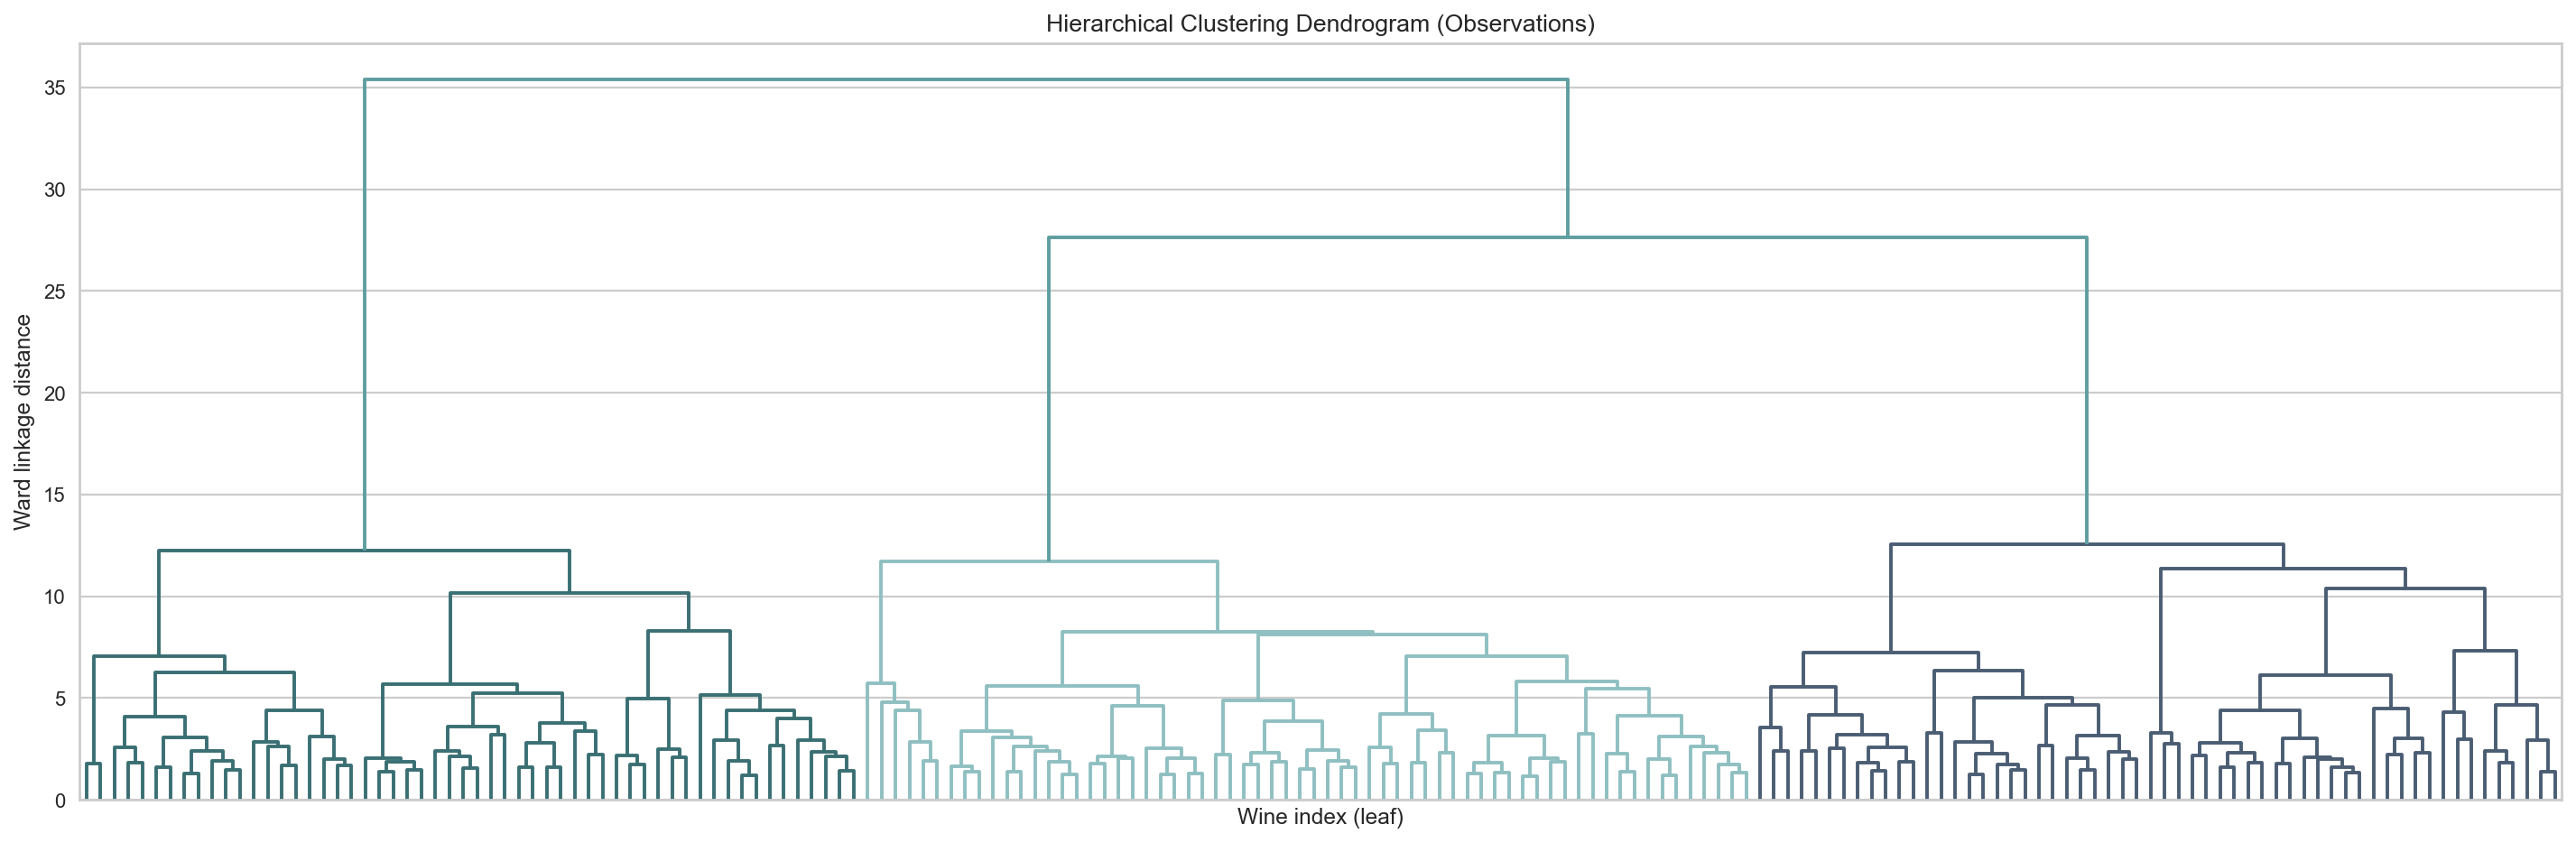

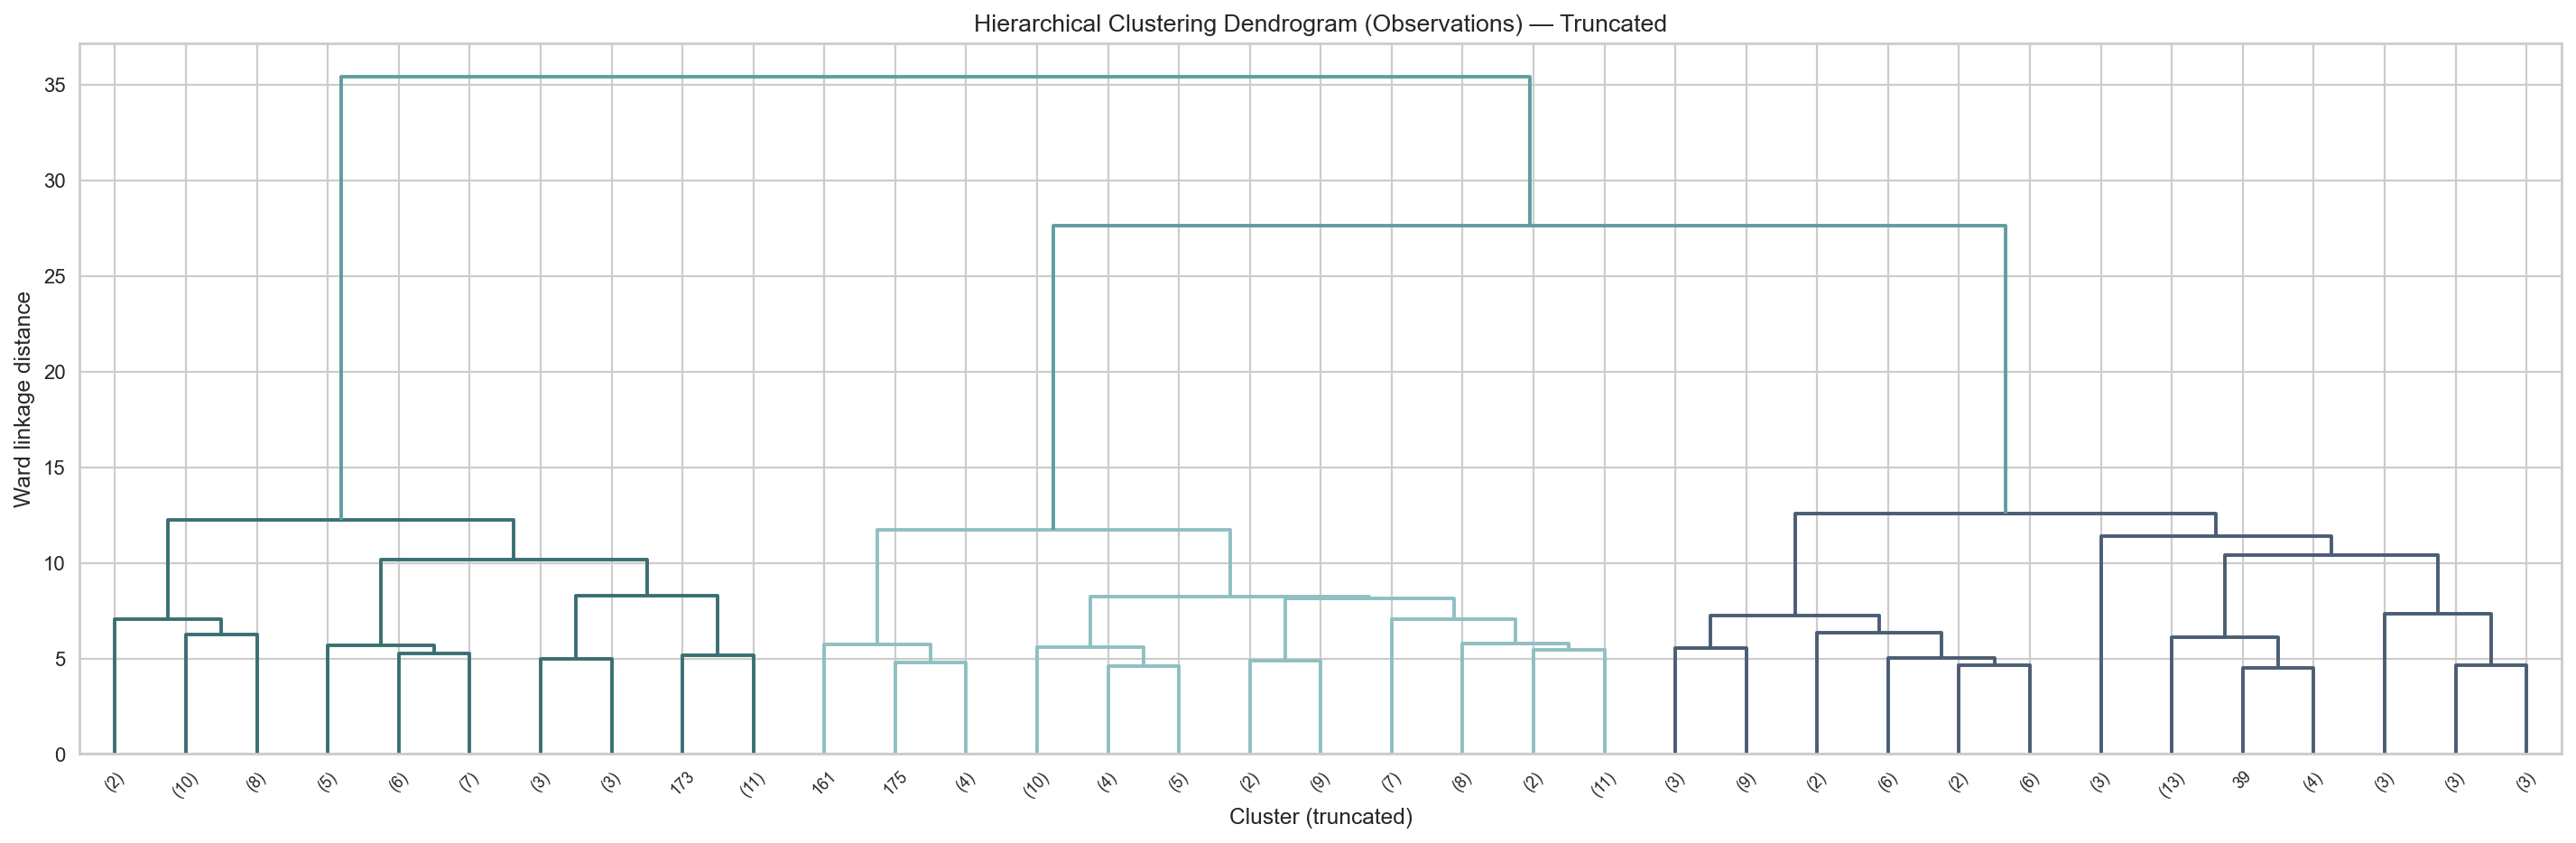

In [20]:
# Dendrogram for observations (wines)
plt.figure(figsize=(18, 6), dpi=160)
plt.title('Hierarchical Clustering Dendrogram (Observations)')
plt.xlabel('Wine index (leaf)')
plt.ylabel("Ward linkage distance")

# Full dendrogram can get busy; we hide leaf labels for readability.
dendrogram(row_linkage, no_labels=True)
plt.tight_layout()
plt.show()

# Truncated view (more readable)
plt.figure(figsize=(18, 6), dpi=160)
plt.title('Hierarchical Clustering Dendrogram (Observations) — Truncated')
plt.xlabel('Cluster (truncated)')
plt.ylabel("Ward linkage distance")
dendrogram(row_linkage, truncate_mode='lastp', p=35)
plt.tight_layout()
plt.show()

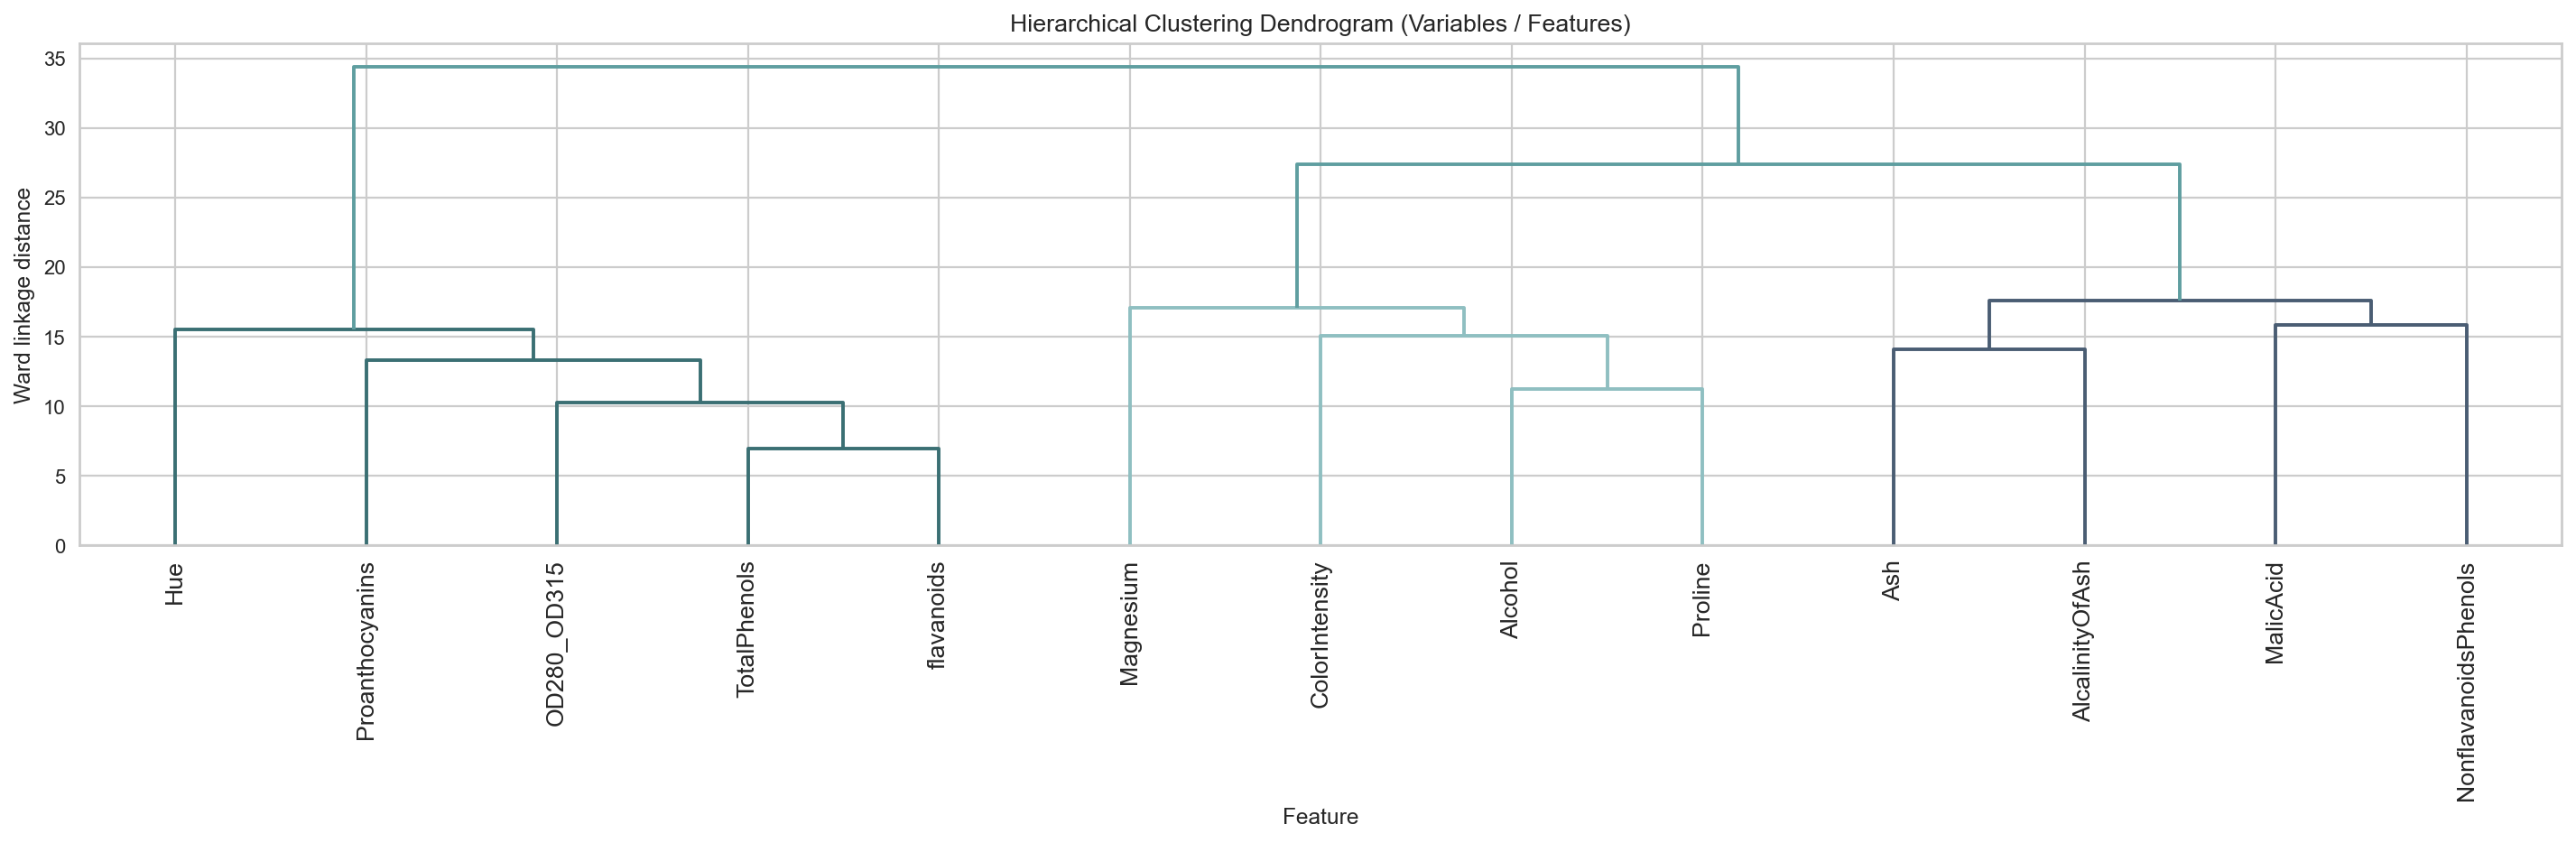

In [21]:
# Dendrogram for variables (features)
plt.figure(figsize=(18, 6), dpi=160)
plt.title('Hierarchical Clustering Dendrogram (Variables / Features)')
plt.xlabel('Feature')
plt.ylabel("Ward linkage distance")
dendrogram(col_linkage, labels=feature_cols, leaf_rotation=90)
plt.tight_layout()
plt.show()

Kan je deze vergelijken met de correlatiematrix?


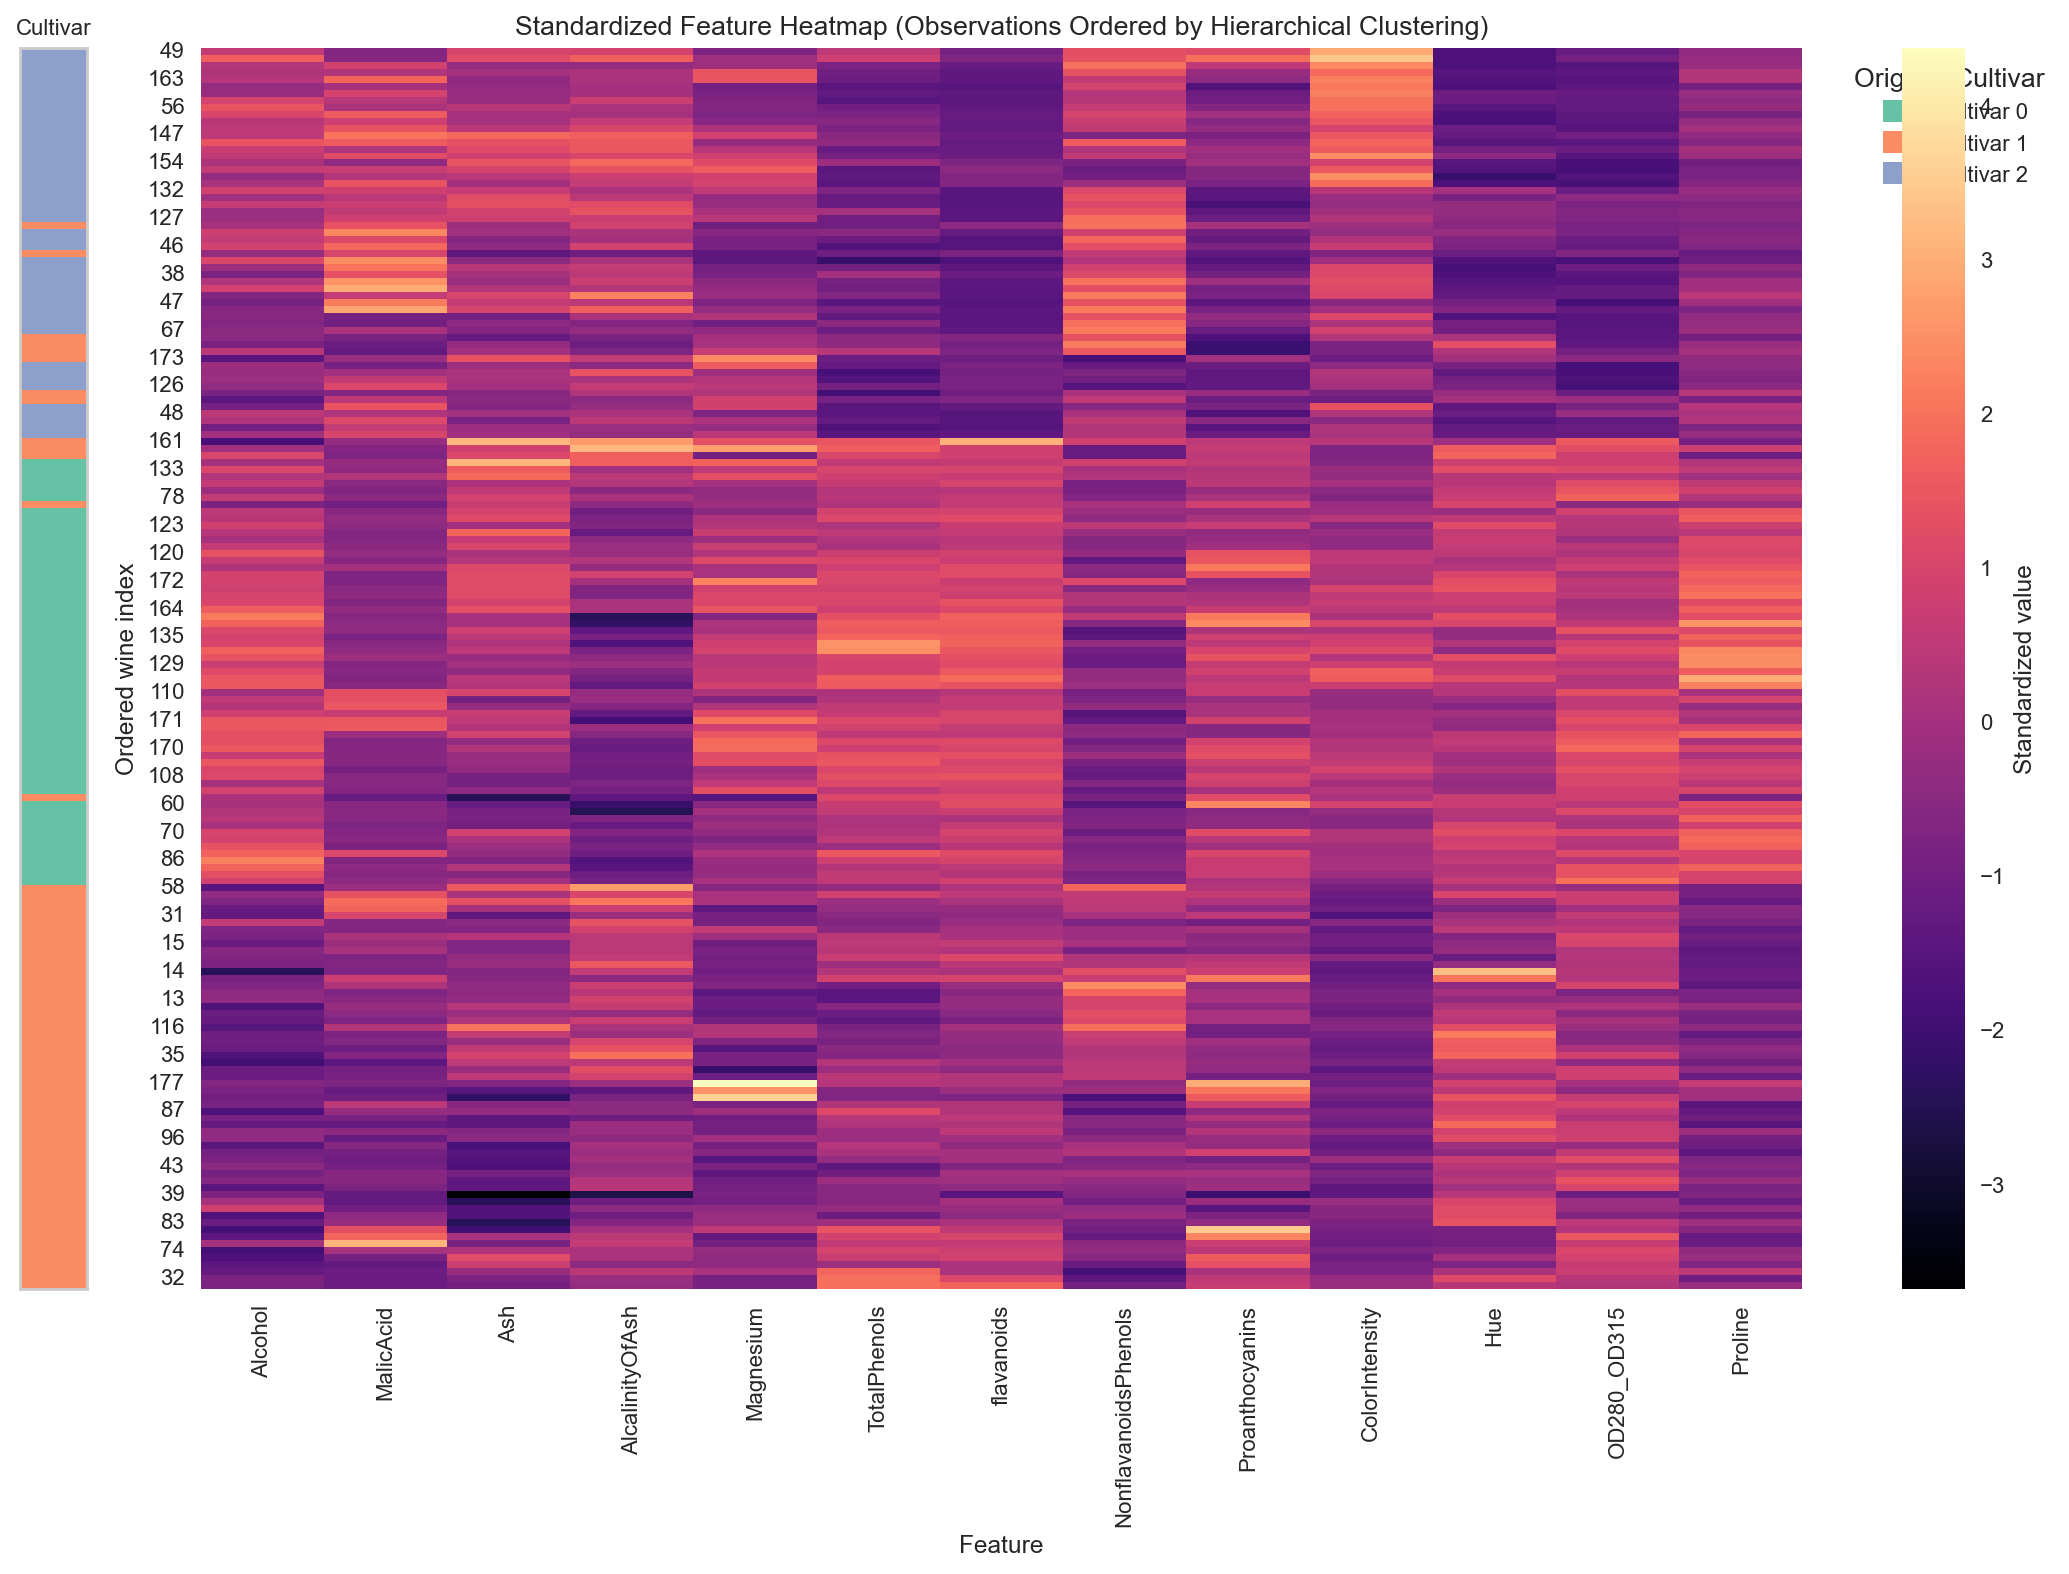

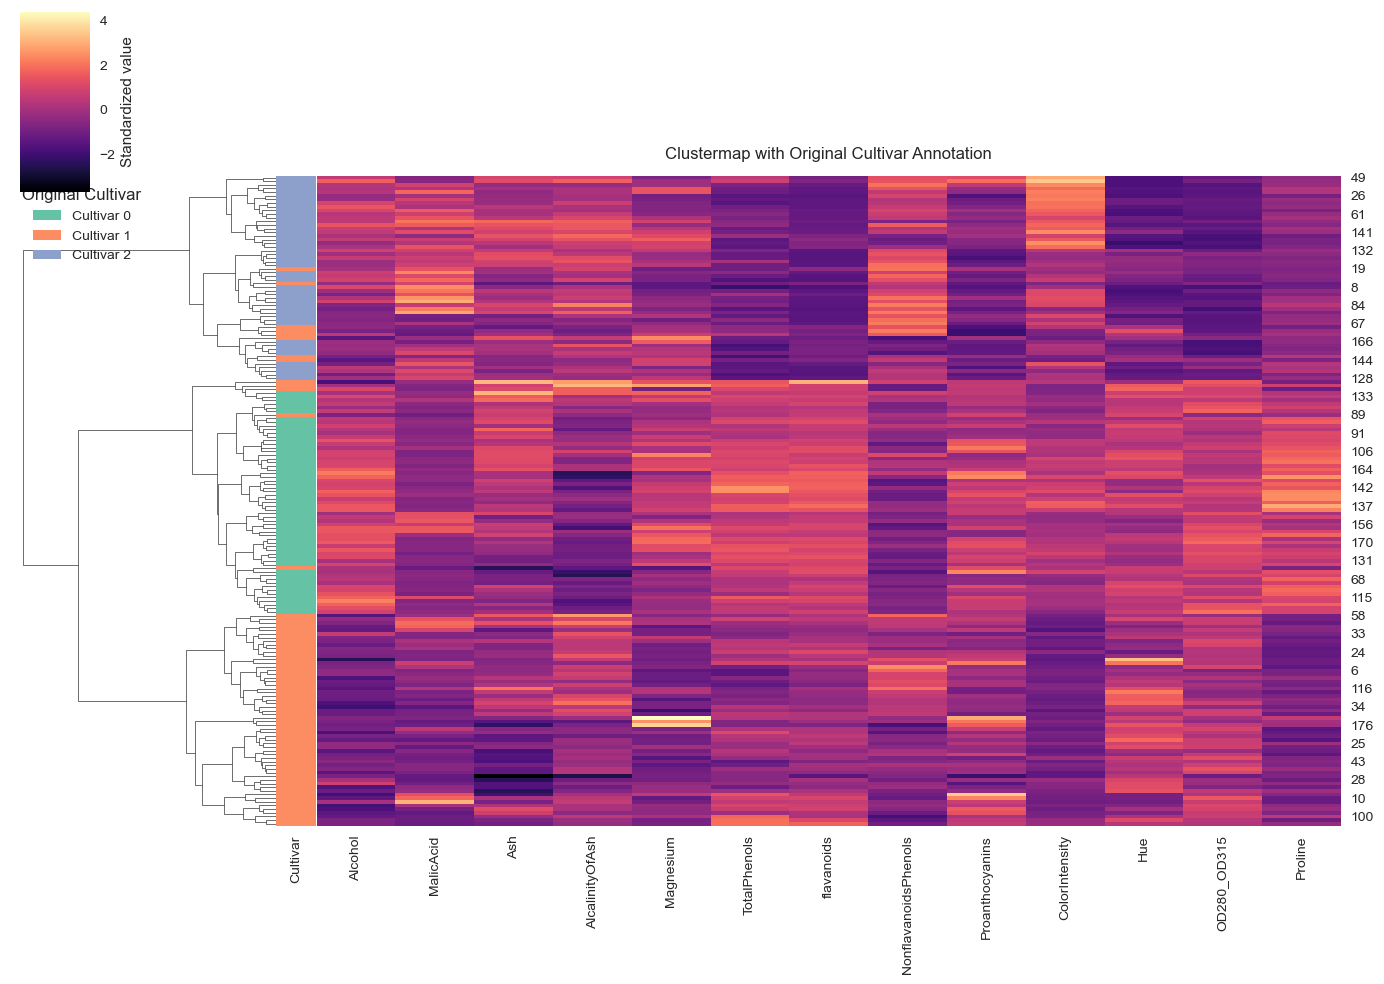

In [23]:
# Plot again with observations ordered by the hierarchical clustering
# NOTE: Cultivar is used only as annotation, not as clustering input.
ordered_row_idx = leaves_list(row_linkage)
X_scaled_ordered = X_scaled_df.iloc[ordered_row_idx]

# Build cultivar color mapping (annotation only)
cultivar_series = df['Cultivar'].astype(str)
cultivar_levels = sorted(cultivar_series.unique())
cultivar_palette = dict(zip(cultivar_levels, sns.color_palette('Set2', n_colors=len(cultivar_levels))))

# Colors aligned to ordered rows for the ordered heatmap
ordered_cultivar = cultivar_series.loc[X_scaled_ordered.index]
ordered_row_colors = ordered_cultivar.map(cultivar_palette)

# Two-panel figure: left = cultivar strip, right = standardized feature heatmap
fig, (ax_left, ax_heat) = plt.subplots(
	1, 2, figsize=(14, 10), dpi=160, gridspec_kw={'width_ratios': [0.4, 12]}
)

cultivar_rgb = np.array([cultivar_palette[c] for c in ordered_cultivar]).reshape(-1, 1, 3)
ax_left.imshow(cultivar_rgb, aspect='auto')
ax_left.set_title('Cultivar', fontsize=10)
ax_left.set_xticks([])
ax_left.set_yticks([])

sns.heatmap(
	X_scaled_ordered,
	cmap='magma',
	cbar_kws={'label': 'Standardized value'},
	ax=ax_heat
)
ax_heat.set_title('Standardized Feature Heatmap (Observations Ordered by Hierarchical Clustering)')
ax_heat.set_xlabel('Feature')
ax_heat.set_ylabel('Ordered wine index')

# Legend for cultivar colors
handles = [
	plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=cultivar_palette[c], markersize=10, label=f'Cultivar {c}')
	for c in cultivar_levels
]
ax_heat.legend(handles=handles, title='Original Cultivar', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Clustermap version (clustering still only on X_scaled_df), with cultivar row annotation
row_colors_full = cultivar_series.map(cultivar_palette)
cg = sns.clustermap(
	X_scaled_df,
	row_linkage=row_linkage,
	col_cluster=False,
	row_colors=row_colors_full,
	cmap='magma',
	figsize=(14, 10),
	cbar_kws={'label': 'Standardized value'}
)
cg.ax_heatmap.set_title('Clustermap with Original Cultivar Annotation', pad=12)

# Add cultivar legend to clustermap
for c in cultivar_levels:
	cg.ax_row_dendrogram.bar(0, 0, color=cultivar_palette[c], label=f'Cultivar {c}', linewidth=0)
cg.ax_row_dendrogram.legend(title='Original Cultivar', loc='upper left', bbox_to_anchor=(0, 1))
plt.show()

<h1 style="
    background-color: #F4F6F7;
    color: #2C3E50;
    padding: 20px;
    text-align: center;
    border-radius: 10px;
    border-left: 8px solid #5F9EA0;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
3. Heuristic Segmentation (Manual Logic)</h1>

We build a simple baseline segmentation using two intuitive chemistry features:
- **Alcohol**: a proxy for body/strength
- **ColorIntensity**: a proxy for intensity/extraction

We split each feature by its median to form 4 quadrants (high/low alcohol × high/low color intensity).

In [8]:
alcohol_median = df['Alcohol'].median()
color_median = df['ColorIntensity'].median()

def classify_wine(row):
    high_alcohol = row['Alcohol'] >= alcohol_median
    high_color = row['ColorIntensity'] >= color_median

    if high_alcohol and high_color:
        return 'High Alcohol / High Color'
    if high_alcohol and not high_color:
        return 'High Alcohol / Low Color'
    if (not high_alcohol) and high_color:
        return 'Low Alcohol / High Color'
    return 'Low Alcohol / Low Color'

df['Heuristic_Segment'] = df.apply(classify_wine, axis=1)
display(df['Heuristic_Segment'].value_counts())

Heuristic_Segment
High Alcohol / High Color    69
Low Alcohol / Low Color      67
High Alcohol / Low Color     22
Low Alcohol / High Color     20
Name: count, dtype: int64

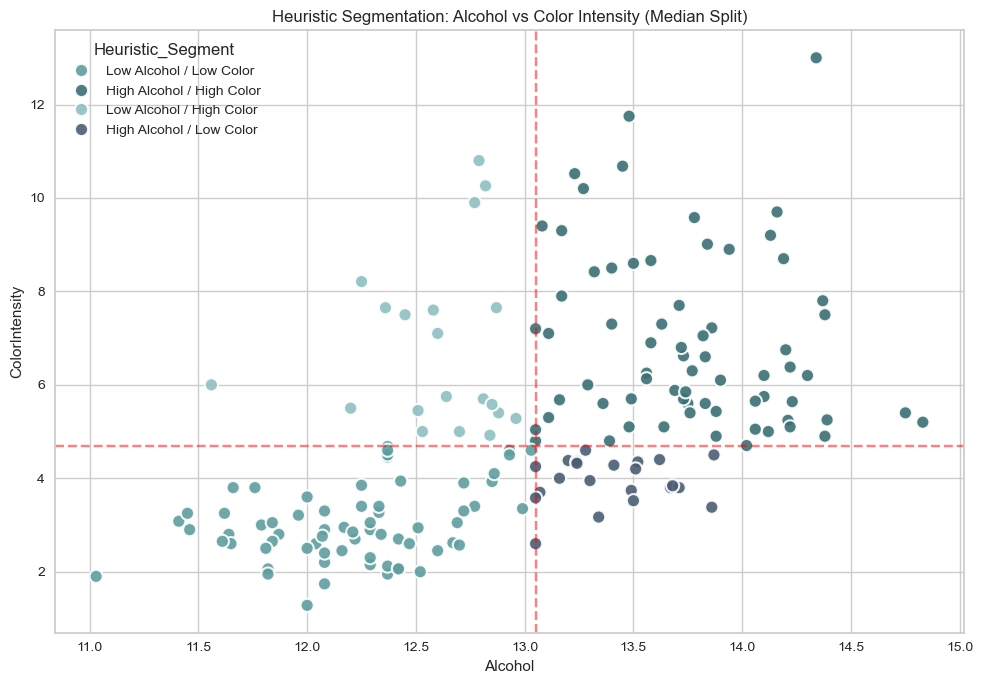

In [9]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='Alcohol',
    y='ColorIntensity',
    hue='Heuristic_Segment',
    s=90,
    edgecolor='white',
    linewidth=1.5,
    alpha=0.9
)
plt.axvline(alcohol_median, color='red', linestyle='--', alpha=0.5)
plt.axhline(color_median, color='red', linestyle='--', alpha=0.5)
plt.title('Heuristic Segmentation: Alcohol vs Color Intensity (Median Split)')
plt.tight_layout()
plt.show()

This does not seem to be a good split since there is no indication of cluster formation. 
From the EDA scatter matrix however we do see some cluster formation between the variables proline and OD280_OD315. Let's have a look into that.

Heuristic_Segment_Proline_OD
High Proline / High OD280_OD315    57
Low Proline / Low OD280_OD315      55
Low Proline / High OD280_OD315     34
High Proline / Low OD280_OD315     32
Name: count, dtype: int64

Heuristic_Segment_Proline_OD
High Proline / High OD280_OD315    57
Low Proline / Low OD280_OD315      55
Low Proline / High OD280_OD315     34
High Proline / Low OD280_OD315     32
Name: count, dtype: int64

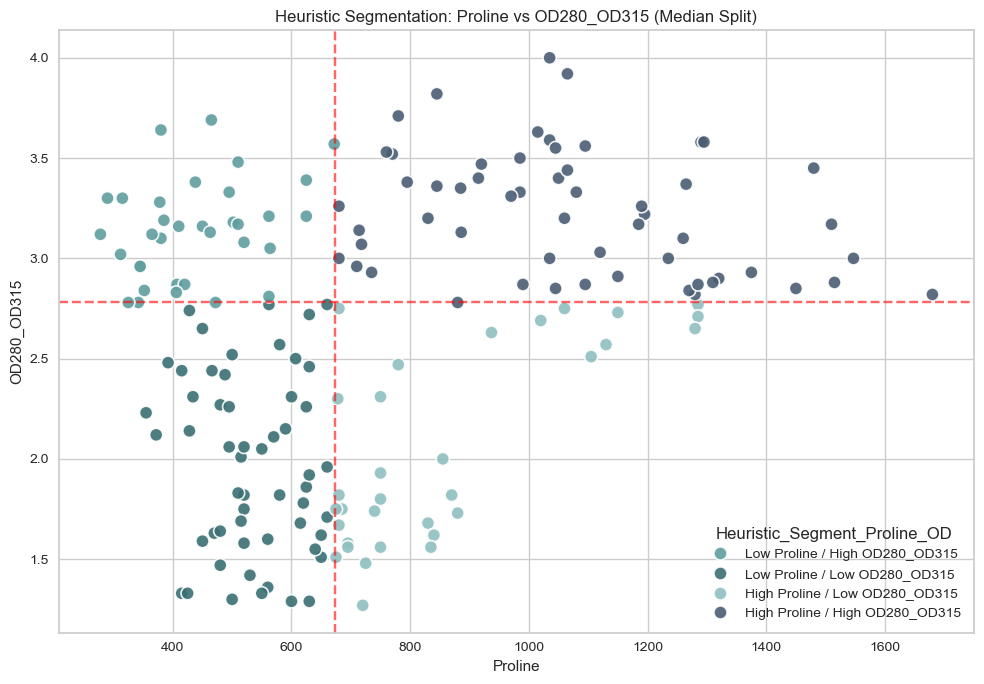

In [11]:
proline_median = df['Proline'].median()
od_median = df['OD280_OD315'].median()

def classify_wine_proline_od(row):
    high_proline = row['Proline'] >= proline_median
    high_od = row['OD280_OD315'] >= od_median

    if high_proline and high_od:
        return 'High Proline / High OD280_OD315'
    if high_proline and not high_od:
        return 'High Proline / Low OD280_OD315'
    if (not high_proline) and high_od:
        return 'Low Proline / High OD280_OD315'
    return 'Low Proline / Low OD280_OD315'

df['Heuristic_Segment_Proline_OD'] = df.apply(classify_wine_proline_od, axis=1)

display(df['Heuristic_Segment_Proline_OD'].value_counts())

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='Proline',
    y='OD280_OD315',
    hue='Heuristic_Segment_Proline_OD',
    s=90,
    edgecolor='white',
    linewidth=1.2,
    alpha=0.9
)
plt.axvline(proline_median, color='red', linestyle='--', alpha=0.6)
plt.axhline(od_median, color='red', linestyle='--', alpha=0.6)
plt.title('Heuristic Segmentation: Proline vs OD280_OD315 (Median Split)')
plt.tight_layout()
plt.show()

Let's have a peek on the real labels:

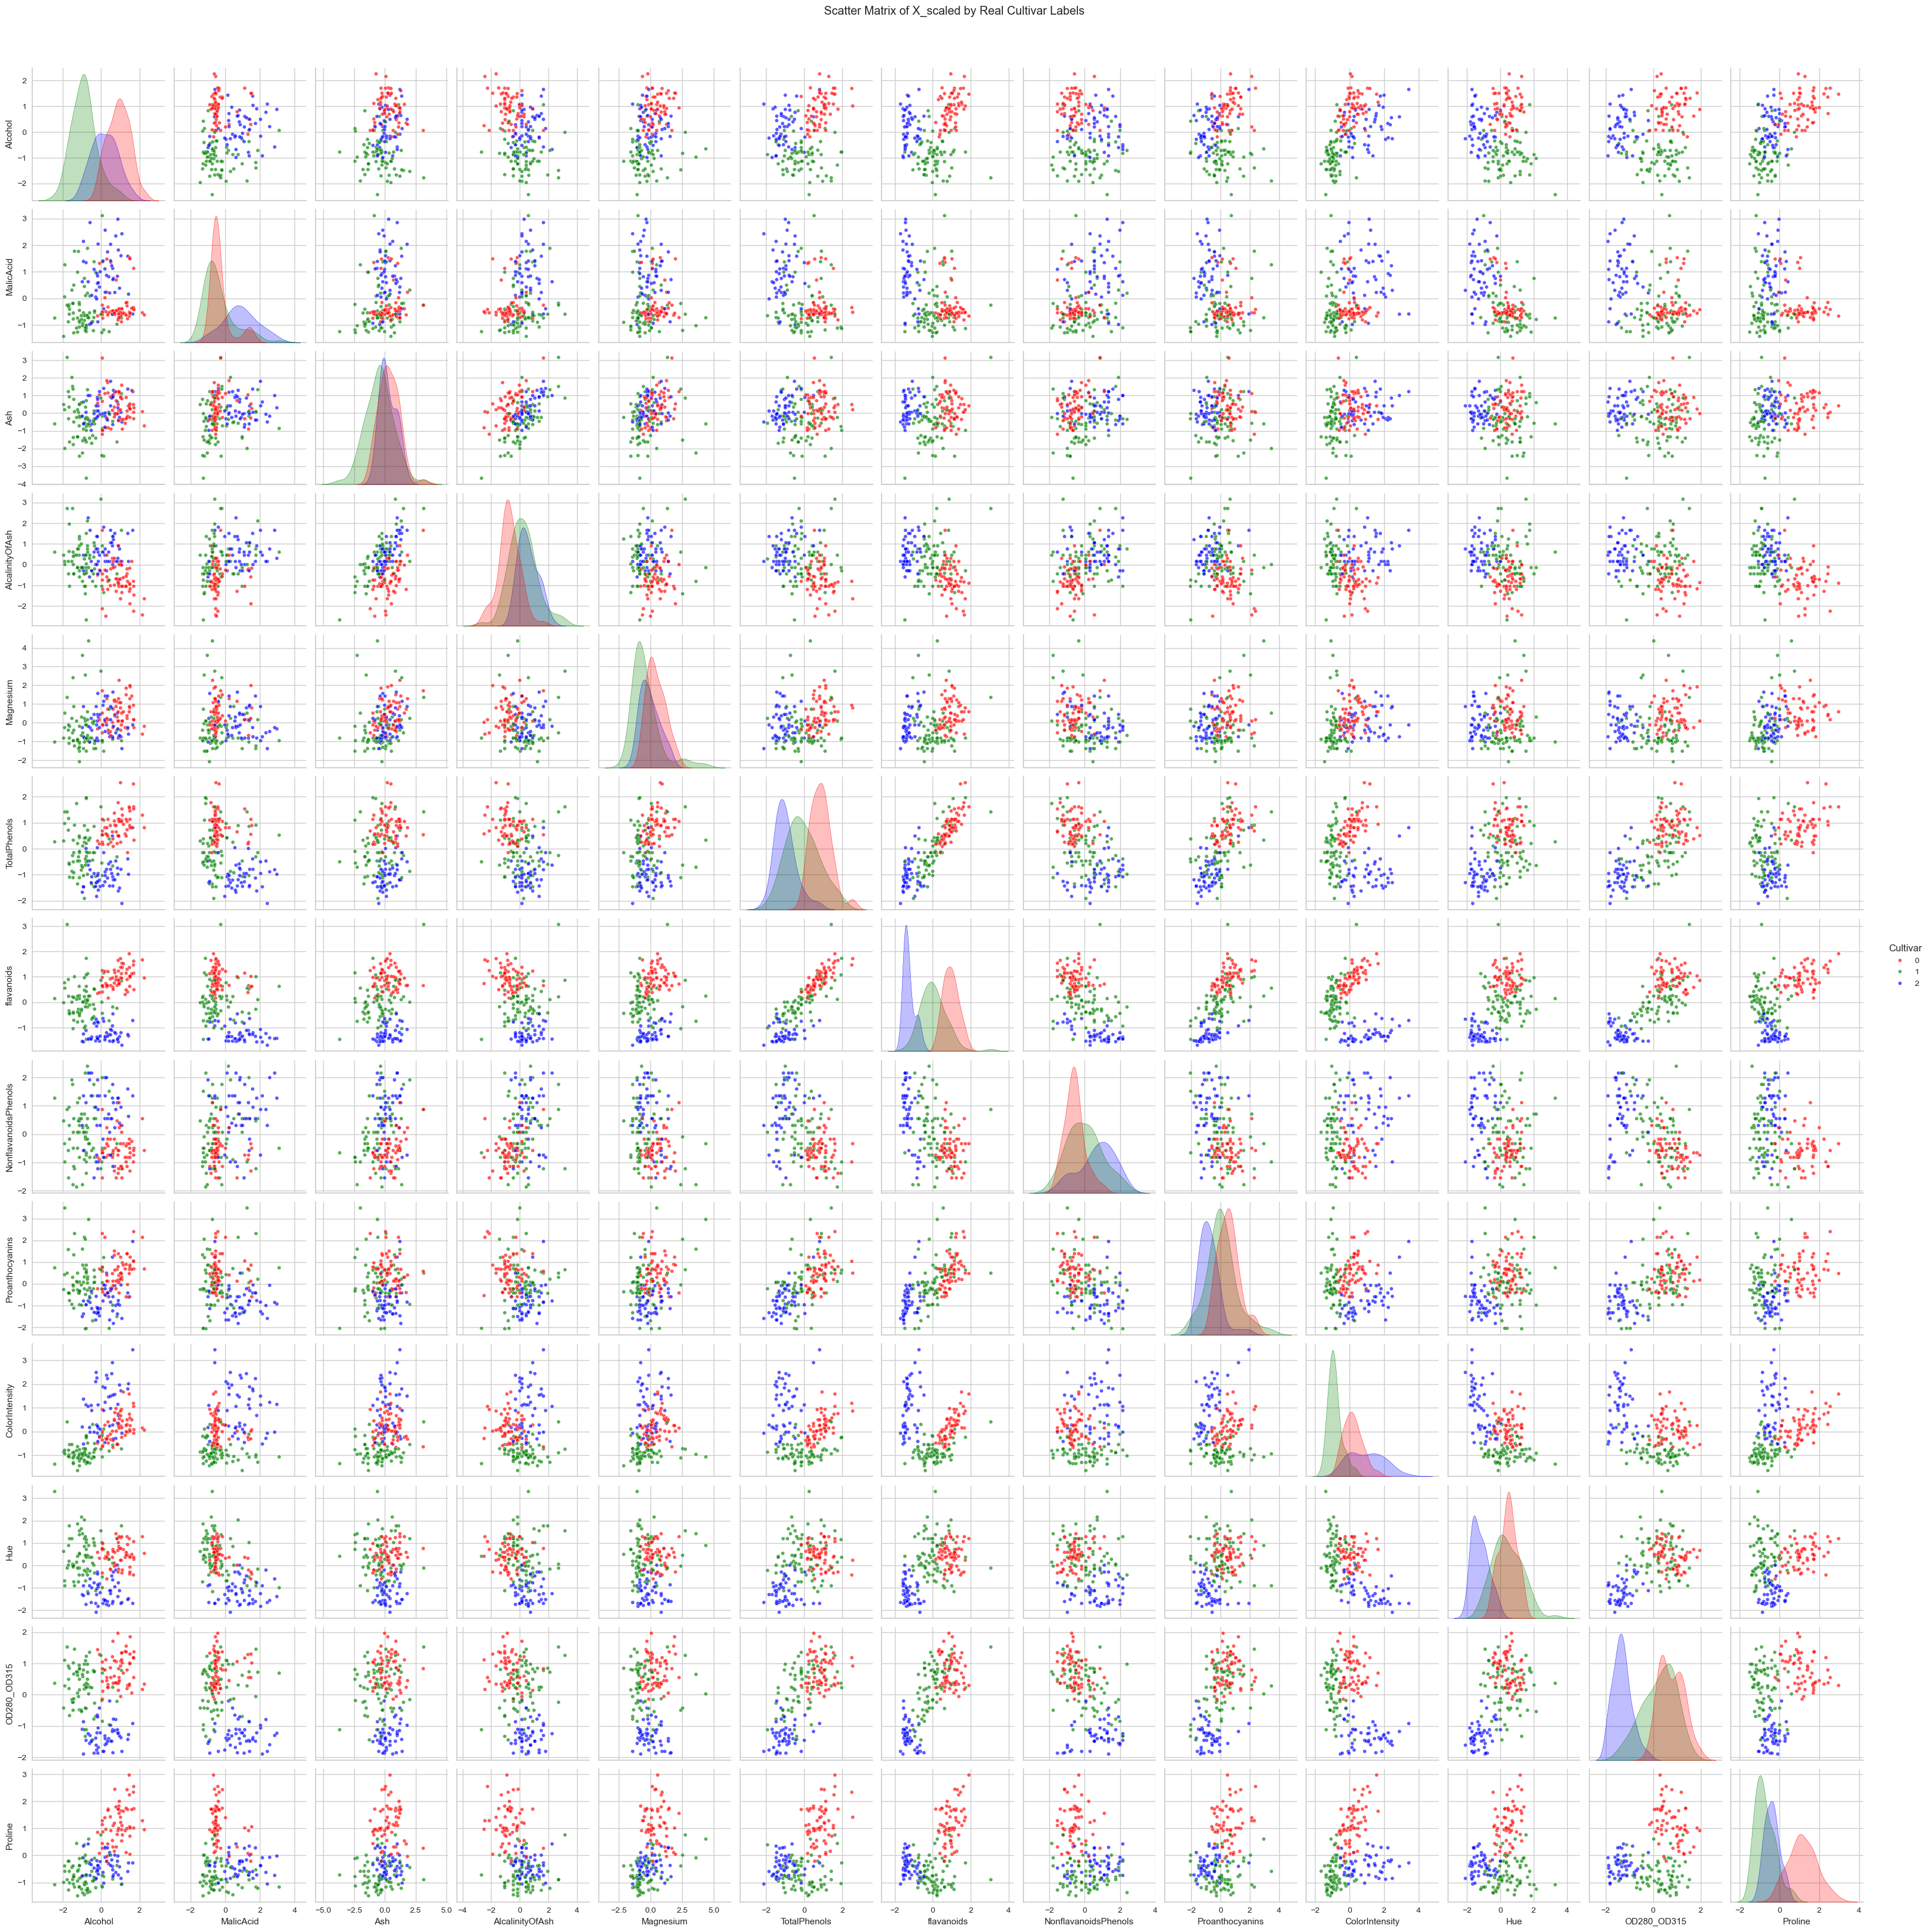

In [13]:
# Scatter matrix of standardized features with real cultivar labels
plot_df = X_scaled_df.copy()
plot_df['Cultivar'] = df['Cultivar'].astype(str)

cultivar_order = sorted(plot_df['Cultivar'].unique())
cultivar_palette = {c: col for c, col in zip(cultivar_order, ['red', 'green', 'blue'])}

g = sns.pairplot(
    plot_df,
    vars=feature_cols,
    hue='Cultivar',
    hue_order=cultivar_order,
    diag_kind='kde',
    plot_kws={'alpha': 0.65, 's': 20, 'edgecolor': 'white', 'linewidth': 0.4},
    palette=cultivar_palette
)

g.figure.suptitle('Scatter Matrix of X_scaled by Real Cultivar Labels', y=1.02)
plt.show()

<h1 style="
    background-color: #F4F6F7;
    color: #2C3E50;
    padding: 20px;
    text-align: center;
    border-radius: 10px;
    border-left: 8px solid #5F9EA0;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
4. K-Means Clustering Implementation</h1>

<h2 style="
    color: #3A6F73;
    font-size: 22px;
    margin-top: 30px;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    border-bottom: 2px solid #E0E6E8;
    padding-bottom: 8px;
">4.1 Determining Optimal Clusters (K)</h2>

We use the **Elbow Method** and a **Silhouette Plot** to select a sensible number of clusters.

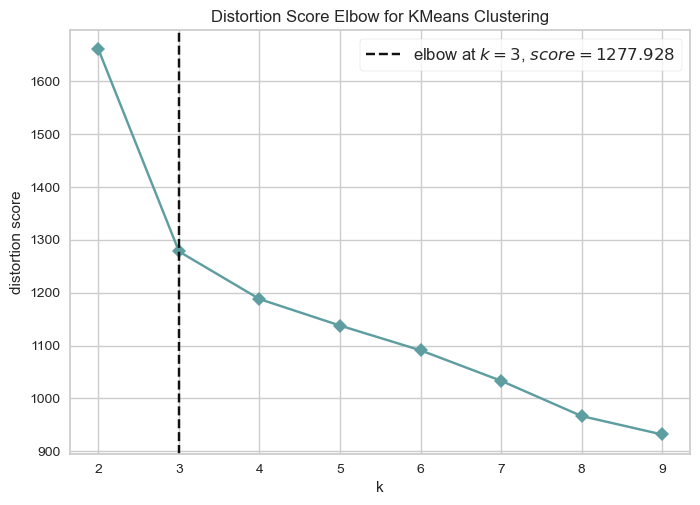

Elbow suggests K = 3


In [14]:
model = KMeans(random_state=RANDOM_STATE, n_init='auto')
visualizer = KElbowVisualizer(model, k=(2, 10), timings=False)
visualizer.fit(X_scaled)
visualizer.show()

best_k = visualizer.elbow_value_ if visualizer.elbow_value_ is not None else 3
print('Elbow suggests K =', best_k)

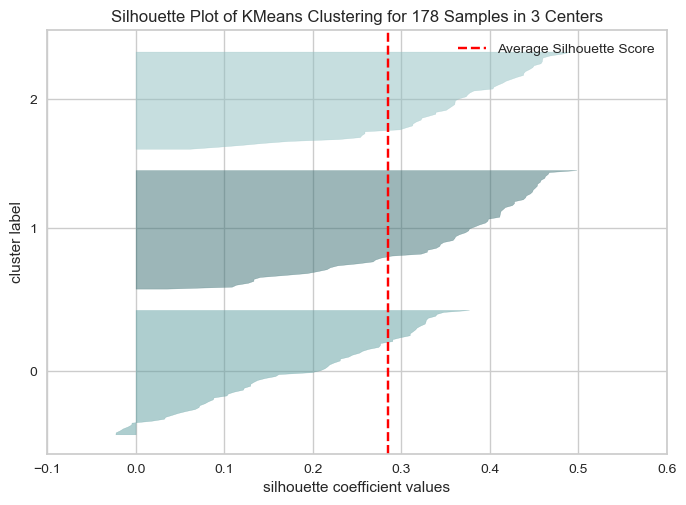

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 178 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [15]:
model_k = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init='auto')
visualizer = SilhouetteVisualizer(model_k, colors=teal_corporate_palette)
visualizer.fit(X_scaled)
visualizer.show()

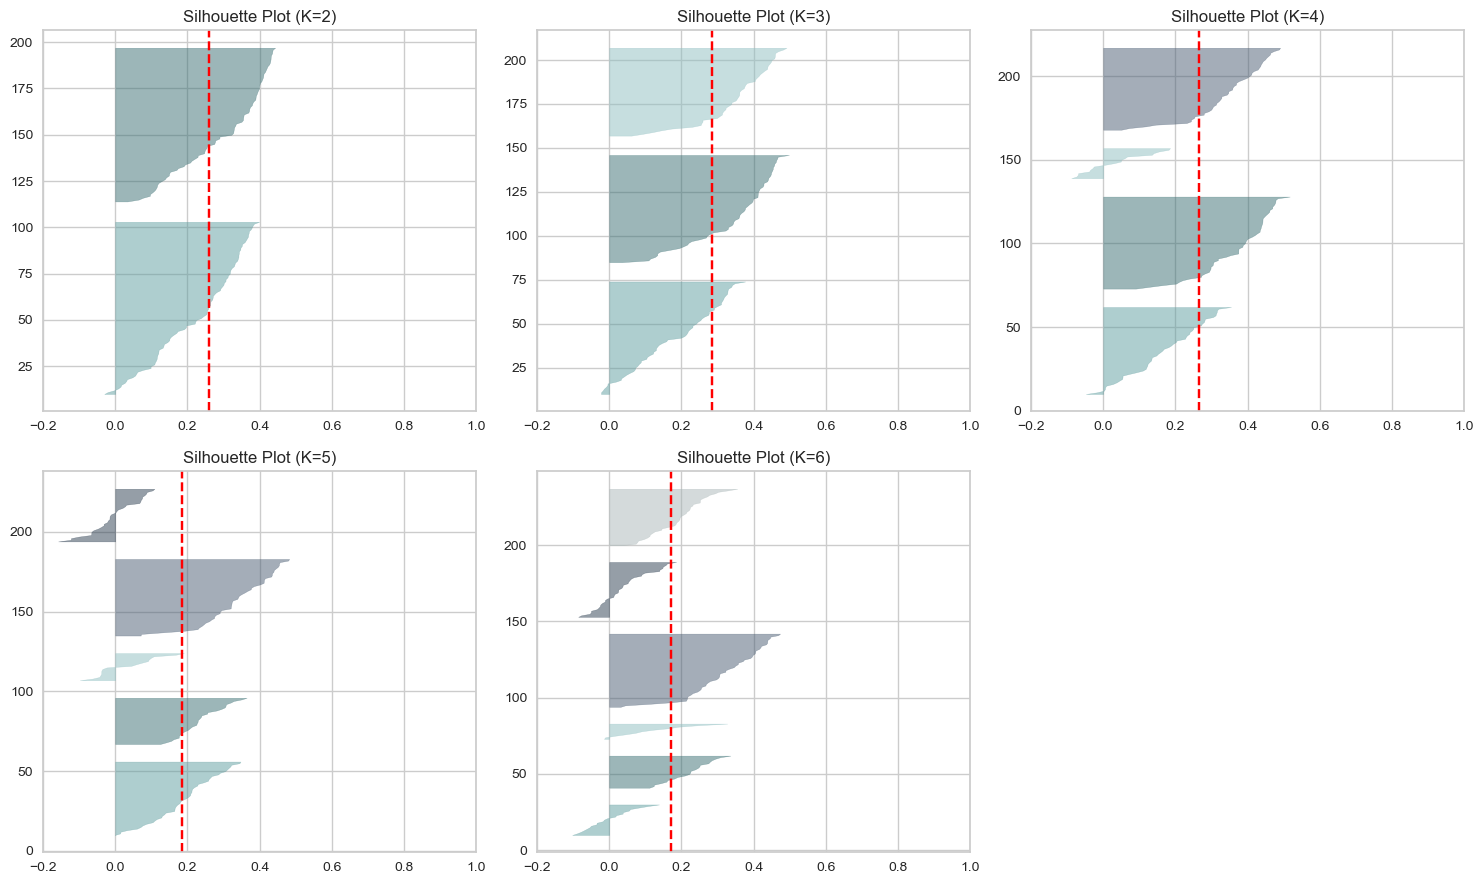

In [17]:
k_values = list(range(2, 7))  # K from 2 to 6
n_cols = 3
n_rows = int(np.ceil(len(k_values) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, k in zip(axes, k_values):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    sv = SilhouetteVisualizer(km, colors=teal_corporate_palette, ax=ax)
    sv.fit(X_scaled)
    ax.set_title(f'Silhouette Plot (K={k})')
    ax.set_xlim(-0.2, 1.0)

# Hide any unused subplot(s)
for ax in axes[len(k_values):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

,k,silhouette_score
0,2,0.259652
1,3,0.284859
2,4,0.265867
3,5,0.184326
4,6,0.170441


Best k by mean silhouette score: k=3 (score=0.285)


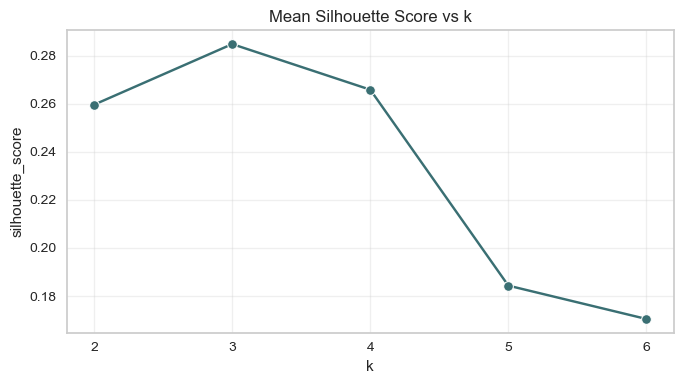

In [18]:
from sklearn.metrics import silhouette_score

k_values = list(range(2, 7))
scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    labels = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

silhouette_df = pd.DataFrame({'k': k_values, 'silhouette_score': scores}).sort_values('k')
display(silhouette_df)

best_row = silhouette_df.iloc[silhouette_df['silhouette_score'].idxmax()]
print(f"Best k by mean silhouette score: k={int(best_row['k'])} (score={best_row['silhouette_score']:.3f})")

plt.figure(figsize=(7, 4))
sns.lineplot(data=silhouette_df, x='k', y='silhouette_score', marker='o', color=my_teal_color)
plt.title('Mean Silhouette Score vs k')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Based on the **mean silhouette scores** for $k=2..6$, the best choice is **$k=3$**:

- $k=2$: 0.260  
- $k=3$: **0.285** (highest)  
- $k=4$: 0.266  
- $k=5$: 0.184  
- $k=6$: 0.170  

Conclusion: **$k=3$ gives the cleanest separation** of clusters (even though the absolute scores are modest, so the structure is only moderately well-separated). From **$k \ge 5$** the sharp drop suggests you’re over-segmenting and creating poorly separated clusters.

<h2 style="
    color: #3A6F73;
    font-size: 22px;
    margin-top: 30px;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    border-bottom: 2px solid #E0E6E8;
    padding-bottom: 8px;
">4.1b Model Selection with Gaussian Mixture Models (GMM)</h2>

K-Means assumes spherical clusters with equal variance. A **Gaussian Mixture Model** can model ellipsoidal clusters and provides a principled way to select the number of clusters/components using information criteria:
- **BIC** (Bayesian Information Criterion)
- **AIC** (Akaike Information Criterion)

Lower is better; BIC penalizes model complexity more strongly than AIC.

,n_components,BIC,AIC
0,1,5741.301901,5410.396412
1,2,5608.349837,4943.357075
2,3,5806.285121,4807.205086
3,4,5604.414743,4271.247435
4,5,5878.400413,4211.145833
5,6,6130.750262,4129.408409
6,7,6560.651423,4225.222297
7,8,6628.378796,3958.862397
8,9,6355.797256,3352.193585
9,10,6479.810455,3142.119511


Best n_components by BIC: 4
Best n_components by AIC: 10


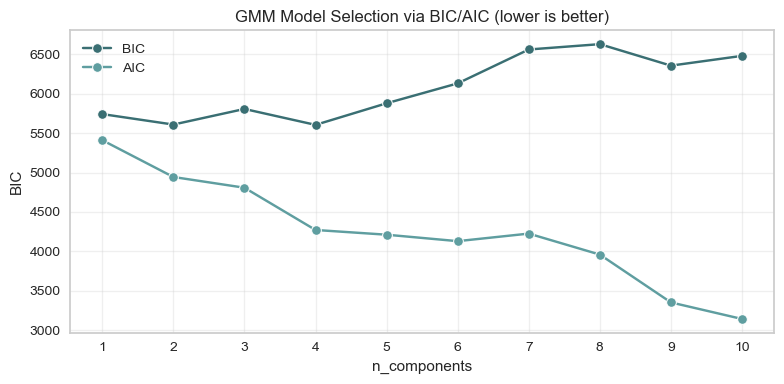

GMM_Cluster
0    61
1     9
2    51
3    57
Name: count, dtype: int64

In [31]:
from sklearn.mixture import GaussianMixture

# Try a range of component counts and compare BIC/AIC
component_range = range(1, 11)
bic = []
aic = []

for n_components in component_range:
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full',
        random_state=RANDOM_STATE,
        n_init=10,
    )
    gmm.fit(X_scaled)
    bic.append(gmm.bic(X_scaled))
    aic.append(gmm.aic(X_scaled))

gmm_ic = pd.DataFrame({
    'n_components': list(component_range),
    'BIC': bic,
    'AIC': aic,
})
display(gmm_ic)

best_bic_n = int(gmm_ic.loc[gmm_ic['BIC'].idxmin(), 'n_components'])
best_aic_n = int(gmm_ic.loc[gmm_ic['AIC'].idxmin(), 'n_components'])
print(f'Best n_components by BIC: {best_bic_n}')
print(f'Best n_components by AIC: {best_aic_n}')

plt.figure(figsize=(8, 4))
sns.lineplot(data=gmm_ic, x='n_components', y='BIC', marker='o', label='BIC', color=my_teal_color)
sns.lineplot(data=gmm_ic, x='n_components', y='AIC', marker='o', label='AIC', color='#5F9EA0')
plt.title('GMM Model Selection via BIC/AIC (lower is better)')
plt.xticks(list(component_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Fit the chosen GMM (using BIC by default) and store hard cluster assignments
gmm_best = GaussianMixture(
    n_components=best_bic_n,
    covariance_type='full',
    random_state=RANDOM_STATE,
    n_init=10,
).fit(X_scaled)

df['GMM_Cluster'] = gmm_best.predict(X_scaled)
df['GMM_Cluster'].value_counts().sort_index()

### Interpreting AIC vs BIC (why AIC can suggest “too many” clusters)

- **AIC** and **BIC** both reward better fit (higher likelihood) and penalize model complexity.
- For GMMs, the likelihood often keeps improving as you add components (you can “split” one group into multiple subgroups).
- **AIC penalizes complexity more lightly** than BIC, so it often keeps preferring larger `n_components` (especially with `covariance_type='full'`, which has many parameters).
- **BIC penalizes complexity more strongly** (roughly proportional to $\log(n)$), so it more aggressively avoids overfitting and often gives a smaller, more interpretable number of clusters.

So if AIC suggests 10 while BIC suggests 4, a reasonable conclusion is:
- There is *some* additional fine-grained structure that improves fit, but
- 10 components is likely **over-segmentation** for interpretation (it may just be splitting cultivars into subclusters).

For this course-style segmentation, **BIC is usually the better default** when you want an interpretable cluster count.

GMM_Cluster,0,1,2,3
Cultivar,,,,
0,0,3,0,56
1,61,6,3,1
2,0,0,48,0


GMM_Cluster,0,1,2,3
Cultivar,,,,
0,0.0%,5.1%,0.0%,94.9%
1,85.9%,8.5%,4.2%,1.4%
2,0.0%,0.0%,100.0%,0.0%


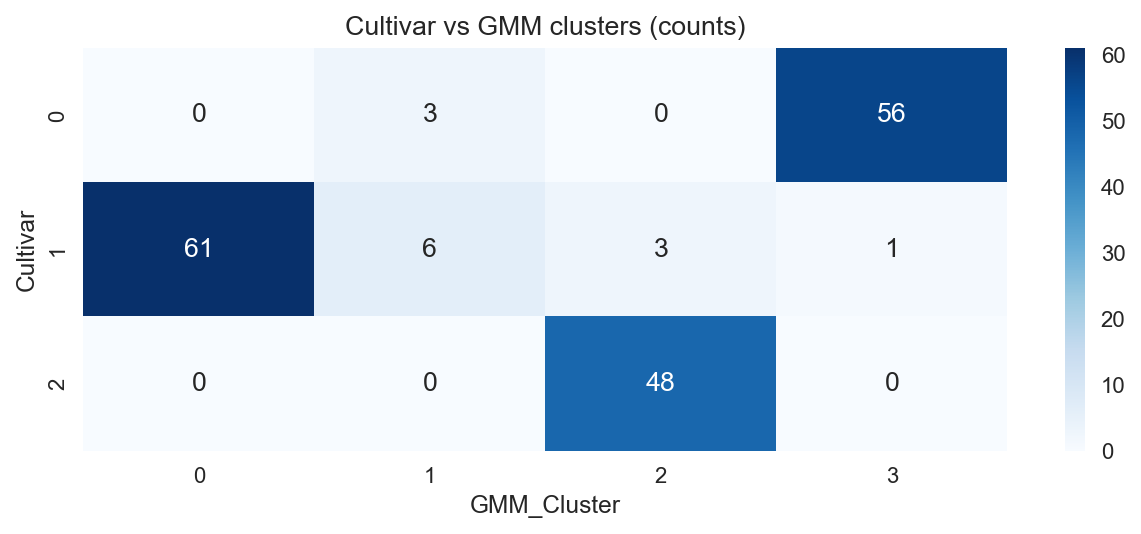

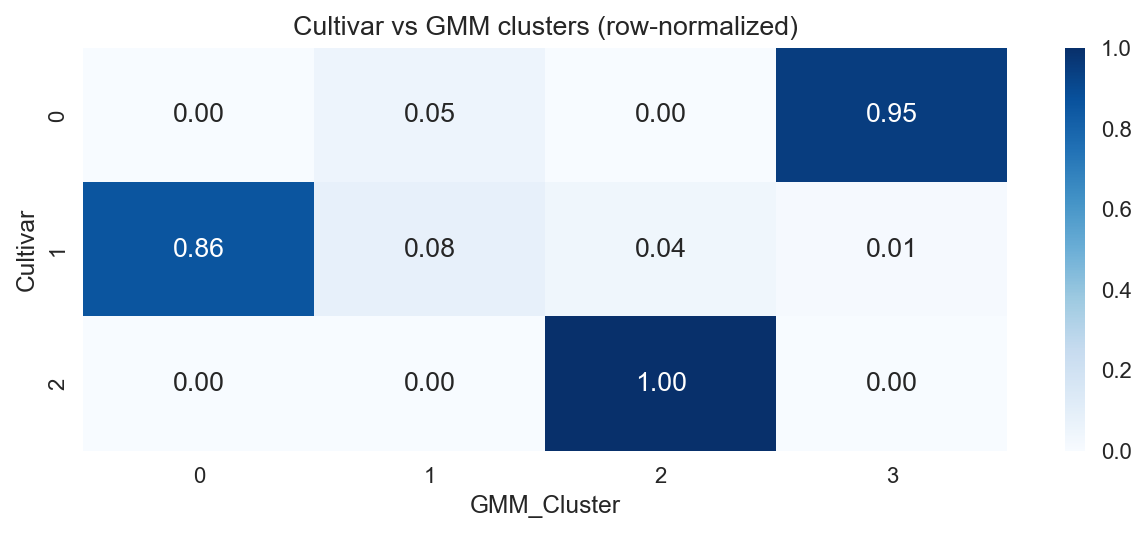

,Mapped_Cultivar,Purity
0,1,100.0%
1,1,66.7%
2,2,94.1%
3,0,98.2%


GMM_Cluster_Mapped,0,1,2
Cultivar,,,
0,56,3,0
1,1,67,3
2,0,0,48


Overall match rate after majority-vote mapping: 96.1%


In [32]:
# Cultivar vs GMM clusters ("confusion matrix" style)

# 3 cultivars x 4 clusters (if BIC picked 4 components)
ct = pd.crosstab(
    df['Cultivar'].astype(str),
    df['GMM_Cluster'],
    rownames=['Cultivar'],
    colnames=['GMM_Cluster'],
)
display(ct)

# Row-normalized: within each cultivar, how points distribute across clusters
ct_row_norm = ct.div(ct.sum(axis=1), axis=0)
display(ct_row_norm.style.format('{:.1%}'))

plt.figure(figsize=(8, 3.5), dpi=160)
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Cultivar vs GMM clusters (counts)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3.5), dpi=160)
sns.heatmap(ct_row_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1)
plt.title('Cultivar vs GMM clusters (row-normalized)')
plt.tight_layout()
plt.show()

# Optional: a simple 4->3 mapping via majority vote per cluster (for interpretability)
# Note: because there are 4 clusters but only 3 cultivars, this cannot be a 1-to-1 mapping.
cluster_to_majority_cultivar = ct.T.idxmax(axis=1).to_dict()
cluster_purity = (ct.max(axis=0) / ct.sum(axis=0)).sort_index()

mapping_df = pd.DataFrame({
    'Mapped_Cultivar': pd.Series(cluster_to_majority_cultivar),
    'Purity': cluster_purity,
}).sort_index()
display(mapping_df.style.format({'Purity': '{:.1%}'}))

df['GMM_Cluster_Mapped'] = df['GMM_Cluster'].map(cluster_to_majority_cultivar)
mapped_ct = pd.crosstab(df['Cultivar'].astype(str), df['GMM_Cluster_Mapped'])
display(mapped_ct)

overall_match_rate = (df['Cultivar'].astype(str) == df['GMM_Cluster_Mapped']).mean()
print(f"Overall match rate after majority-vote mapping: {overall_match_rate:.1%}")

<h2 style="
    color: #3A6F73;
    font-size: 22px;
    margin-top: 30px;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    border-bottom: 2px solid #E0E6E8;
    padding-bottom: 8px;
">4.2 Model Fitting & Visualization (PCA Projection)</h2>

Because the wine dataset has many features, we visualize clusters in 2D using **PCA** (Principal Component Analysis).

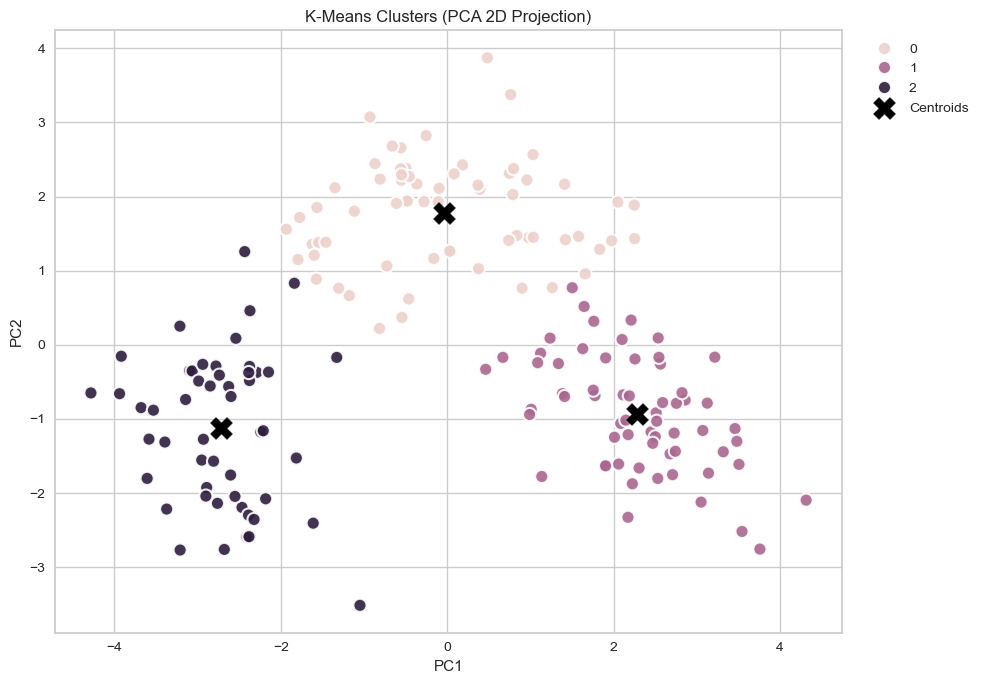

Cluster
0    65
1    62
2    51
Name: count, dtype: int64

In [25]:
kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=RANDOM_STATE, n_init='auto')
df['Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

centroids_scaled = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', s=90, alpha=0.9, edgecolor='white', linewidth=1.5)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=250, c='black', label='Centroids')
plt.title('K-Means Clusters (PCA 2D Projection)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

df['Cluster'].value_counts().sort_index()

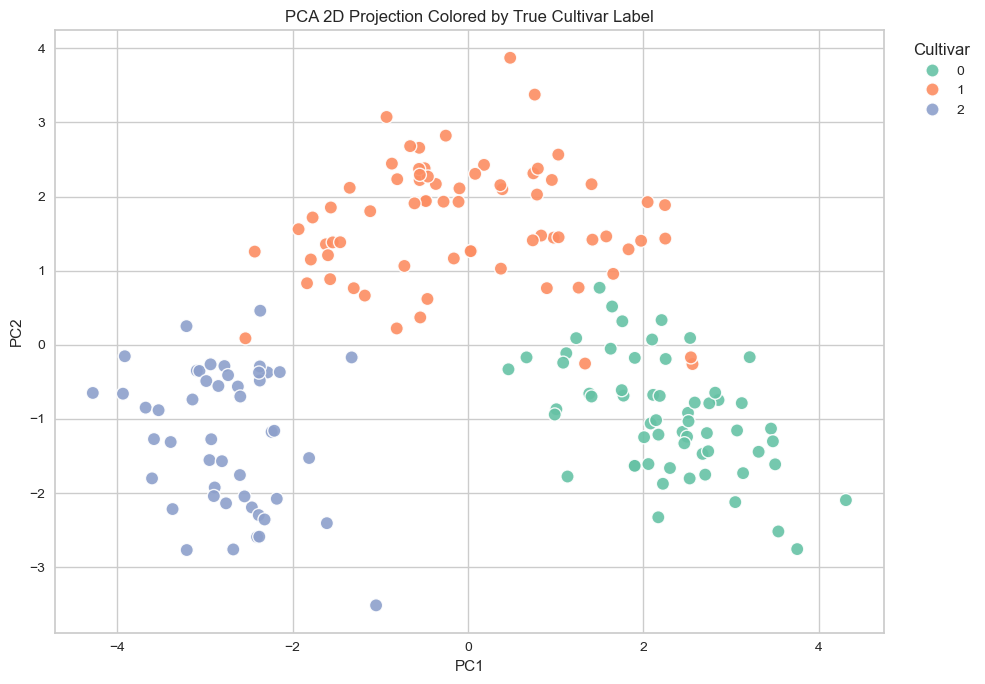

In [27]:
# PCA scatter colored by the real label (Cultivar)
df_pca_plot = df.copy()
df_pca_plot['Cultivar_str'] = df_pca_plot['Cultivar'].astype(str)

cultivar_levels_pca = sorted(df_pca_plot['Cultivar_str'].unique())
cultivar_palette_pca = dict(zip(cultivar_levels_pca, sns.color_palette('Set2', n_colors=len(cultivar_levels_pca))))

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_pca_plot,
    x='PC1',
    y='PC2',
    hue='Cultivar_str',
    hue_order=cultivar_levels_pca,
    palette=cultivar_palette_pca,
    s=90,
    alpha=0.9,
    edgecolor='white',
    linewidth=1.0,
 )
plt.title('PCA 2D Projection Colored by True Cultivar Label')
plt.legend(title='Cultivar', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [26]:
# After: pca = PCA(n_components=2, ...); X_pca = pca.fit_transform(X_scaled)

pc1, pc2 = pca.explained_variance_ratio_
print(f"PC1: {pc1:.3f} ({pc1*100:.1f}%)")
print(f"PC2: {pc2:.3f} ({pc2*100:.1f}%)")
print(f"PC1+PC2: {(pc1+pc2):.3f} ({(pc1+pc2)*100:.1f}%)")

PC1: 0.362 (36.2%)
PC2: 0.192 (19.2%)
PC1+PC2: 0.554 (55.4%)


**55.4% explained variance** means the 2D PCA plot shows the *largest* two directions of variation in the standardized wine chemistry data, and together they cover **a bit more than half** of what varies in the dataset.
The remaining **44.6%** of variance is in PC3, PC4, … so **some structure (including cluster separation)** can live outside the PC1–PC2 plane.

What that implies for your K-Means plot:
- If clusters look **well separated in PC1–PC2**, that’s strong evidence they’re separated in the full space too.
- If clusters look **overlapping in PC1–PC2**, they can still be meaningfully separated in higher dimensions (because K-Means was fit on `X_scaled`, not on the 2 PCs).
- PCA is optimizing variance, not “cluster separability”, so sometimes cluster boundaries aren’t aligned with PC1/PC2.

Practical takeaway: treat the PCA scatter as a **useful visualization**, but don’t judge clustering quality *only* from that picture; use silhouette / profiles to judge separation in the full feature space.

<h1 style="
    background-color: #F4F6F7;
    color: #2C3E50;
    padding: 20px;
    text-align: center;
    border-radius: 10px;
    border-left: 8px solid #5F9EA0;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
5. Cluster Profiling & Interpretation</h1>

We interpret clusters by summarizing the **average chemistry profile** per cluster, then create a descriptive `Cluster_Name` based on high/low values of a few key features.

In [28]:
cluster_profile = df.groupby('Cluster')[feature_cols].mean().T
display(cluster_profile)

Cluster,0,1,2
Alcohol,12.250923,13.676774,13.134118
MalicAcid,1.897385,1.997903,3.307255
Ash,2.231231,2.466290,2.417647
AlcalinityOfAsh,20.063077,17.462903,21.241176
Magnesium,92.738462,107.967742,98.666667
TotalPhenols,2.247692,2.847581,1.683922
flavanoids,2.050000,3.003226,0.818824
NonflavanoidsPhenols,0.357692,0.292097,0.451961
Proanthocyanins,1.624154,1.922097,1.145882
ColorIntensity,2.973077,5.453548,7.234706


In [29]:
# Convert centroids back to original units for labeling
centroids = scaler.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids, columns=feature_cols)
centroid_df['Cluster_ID'] = np.arange(best_k)

medians = df[feature_cols].median()

def label_from_centroid(row, medians_):
    parts = []
    parts.append('High Alcohol' if row['Alcohol'] >= medians_['Alcohol'] else 'Low Alcohol')
    parts.append('High Color' if row['ColorIntensity'] >= medians_['ColorIntensity'] else 'Low Color')
    parts.append('Rich Phenols' if row['TotalPhenols'] >= medians_['TotalPhenols'] else 'Light Phenols')
    return ' / '.join(parts)

centroid_df['Cluster_Name'] = centroid_df.apply(lambda r: label_from_centroid(r, medians), axis=1)
cluster_map = dict(zip(centroid_df['Cluster_ID'], centroid_df['Cluster_Name']))
df['Cluster_Name'] = df['Cluster'].map(cluster_map)

display(centroid_df[['Cluster_ID', 'Cluster_Name', 'Alcohol', 'ColorIntensity', 'TotalPhenols']])
df['Cluster_Name'].value_counts()

,Cluster_ID,Cluster_Name,Alcohol,ColorIntensity,TotalPhenols
0,0,Low Alcohol / Low Color / Light Phenols,12.250923,2.973077,2.247692
1,1,High Alcohol / High Color / Rich Phenols,13.676774,5.453548,2.847581
2,2,High Alcohol / High Color / Light Phenols,13.134118,7.234706,1.683922


Cluster_Name
Low Alcohol / Low Color / Light Phenols      65
High Alcohol / High Color / Rich Phenols     62
High Alcohol / High Color / Light Phenols    51
Name: count, dtype: int64

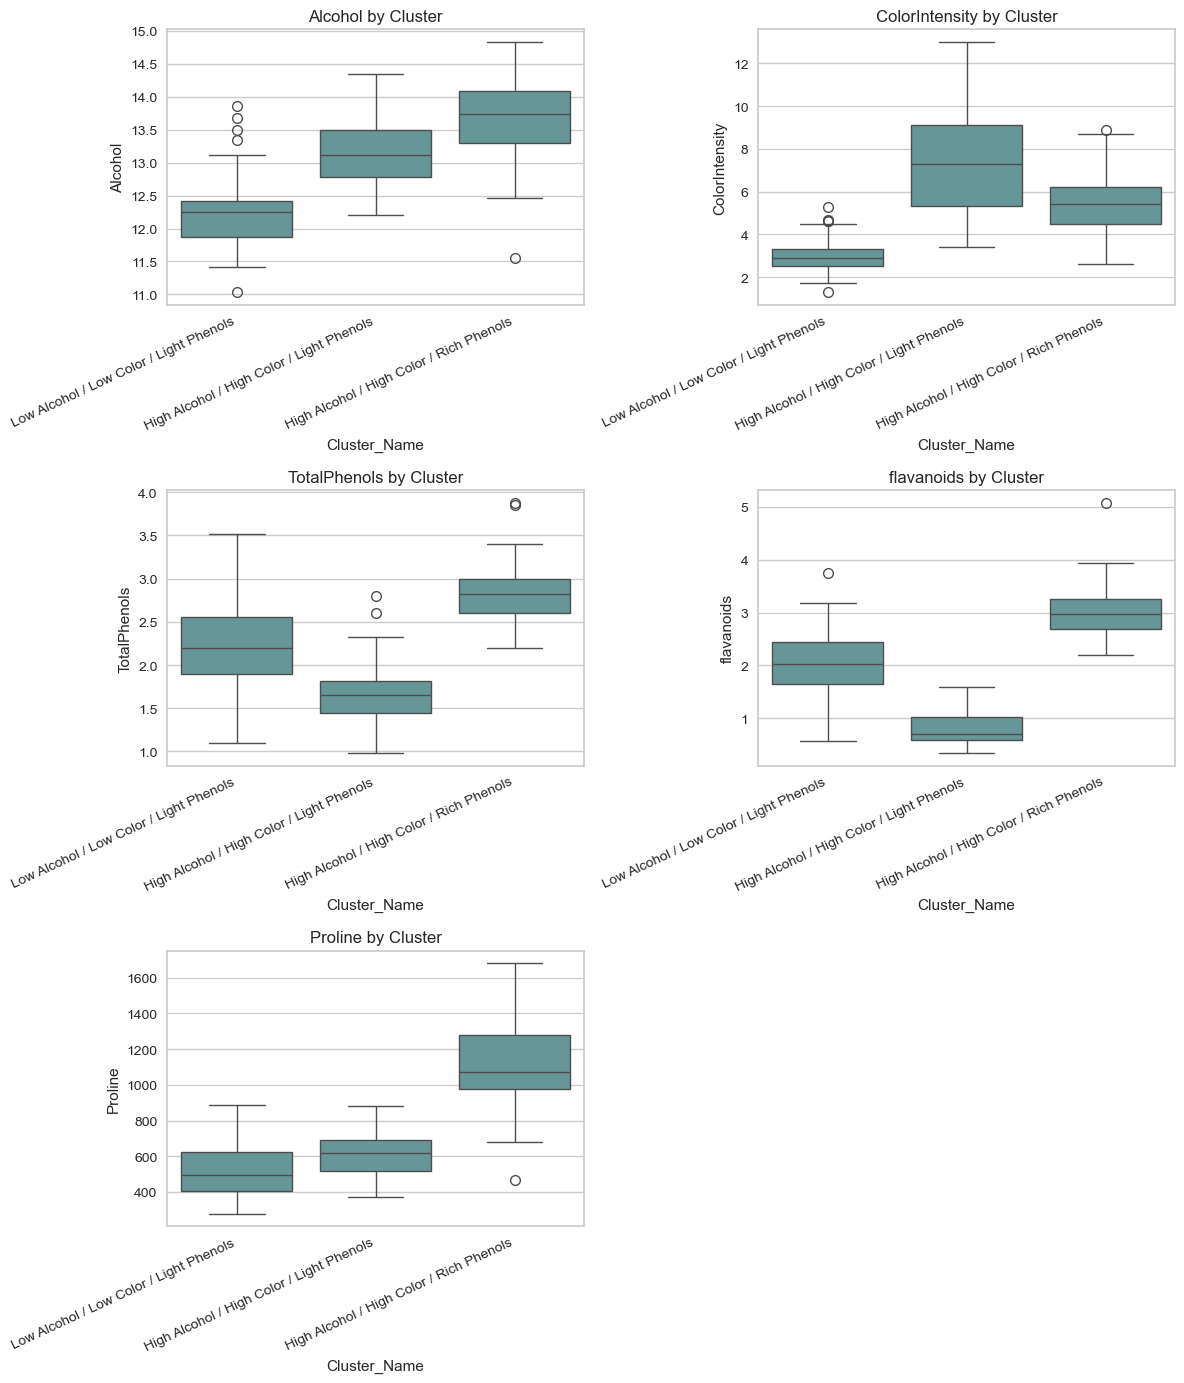

In [30]:
key_features = ['Alcohol', 'ColorIntensity', 'TotalPhenols', 'flavanoids', 'Proline']

plt.figure(figsize=(12, 14))
for i, f in enumerate(key_features, start=1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=df, x='Cluster_Name', y=f)
    plt.xticks(rotation=25, ha='right')
    plt.title(f'{f} by Cluster')

plt.tight_layout()
plt.show()